# Student Performance Clustering Analysis
## AI-Based Data Mining for Educational Analytics

This notebook explores multiple clustering scenarios on the UCI Combined Students dataset to uncover hidden patterns in student performance, behavior, and socio-economic backgrounds.

### Clustering Scenarios:
1. **Academic Performance Clustering**: Group students based on grades, study time, and academic support
2. **Behavioral Pattern Clustering**: Identify student lifestyle patterns (social activities, alcohol consumption, relationships)
3. **Socio-Economic Background Clustering**: Segment students by family education, occupation, and support
4. **Comprehensive Profile Clustering**: Holistic view combining all aspects

### Clustering Algorithms Applied:
1. **K-Means**: Partition-based clustering for clear group separation
2. **Hierarchical Clustering**: Tree-based approach showing nested relationships
3. **DBSCAN**: Density-based method identifying outliers and arbitrary shapes
4. **Gaussian Mixture Models**: Probabilistic clustering with soft assignments

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading and Exploration

In [2]:
# Load the dataset
df = pd.read_csv("/content/uci_combined_students_despite_course.csv")

print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("First few rows:")
print(df.head())
print("\n" + "="*80)
print("\nDataset Info:")
print(df.info())
print("\n" + "="*80)
print("\nNumerical Features Statistics:")
print(df.describe())
print("\n" + "="*80)
print("\nMissing Values:")
print(df.isnull().sum())
print("\n" + "="*80)
print("\nCourse Distribution:")
print(df['course'].value_counts())

Dataset Shape: (1044, 34)

First few rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  freetime goout  Dalc  Walc  health absences  G1  G2  G3       course  
0        3     4     1     1       3        6   5   6   6  Mathematics  
1        3     3     1     1       3        4   5   5   6  Mathematics  
2        3     2     2     3       3       10   7   8  10  Mathematics  
3        2     2     1     1       5        2  15  14  15  Mathematics  
4        3     2     1     2       5        4   6  10  10  Mathematics  

[5 rows x 34 columns]


Dataset

## 2. Data Preprocessing

In [3]:
# Create a copy for processing
df_processed = df.copy()

# Encode categorical variables
label_encoders = {}
categorical_cols = df_processed.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

print("Categorical columns encoded:")
print(list(categorical_cols))
print("\nProcessed dataset shape:", df_processed.shape)
print("\nFirst few rows after encoding:")
print(df_processed.head())

Categorical columns encoded:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'G2', 'course']

Processed dataset shape: (1044, 34)

First few rows after encoding:
   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2     2  ...   

   freetime  goout  Dalc  Walc  health  absences  G1  G2  G3  course  
0         3      4     1     1       3         6   5  14   6       0  
1         3      3     1     1       3         4   5  13   6       0  
2         3      2 

## 3. Define Clustering Scenarios

### Why These Scenarios?

**Scenario 1: Academic Performance Clustering**
- **Purpose**: Identify student groups with similar academic achievements and study patterns
- **Educational Value**: Teachers can tailor interventions for low-performers, provide advanced materials for high-achievers
- **Features**: G1, G2, G3 (grades), studytime, failures, schoolsup, famsup, paid (extra classes)

**Scenario 2: Behavioral Pattern Clustering**
- **Purpose**: Understand lifestyle choices that may impact academic success
- **Educational Value**: Identify at-risk behavioral patterns, design wellness programs
- **Features**: goout, Dalc, Walc (alcohol consumption), freetime, romantic, activities, absences

**Scenario 3: Socio-Economic Background Clustering**
- **Purpose**: Segment students by family circumstances and support systems
- **Educational Value**: Target financial aid, family engagement programs, address equity issues
- **Features**: Medu, Fedu (parent education), Mjob, Fjob (parent jobs), famsize, Pstatus, guardian, internet

**Scenario 4: Comprehensive Student Profile Clustering**
- **Purpose**: Holistic understanding combining academic, behavioral, and socio-economic factors
- **Educational Value**: Personalized learning paths, comprehensive student support strategies
- **Features**: All relevant features combined

In [4]:
# Define feature sets for each clustering scenario

# Scenario 1: Academic Performance
academic_features = ['G1', 'G2', 'G3', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'absences']

# Scenario 2: Behavioral Patterns
behavioral_features = ['goout', 'Dalc', 'Walc', 'freetime', 'romantic', 'activities', 'absences', 'health', 'famrel']

# Scenario 3: Socio-Economic Background
socioeconomic_features = ['Medu', 'Fedu', 'Mjob', 'Fjob', 'famsize', 'Pstatus', 'guardian', 'internet', 'traveltime', 'address']

# Scenario 4: Comprehensive Profile
comprehensive_features = ['age', 'sex', 'address', 'Medu', 'Fedu', 'traveltime', 'studytime',
                         'failures', 'schoolsup', 'famsup', 'activities', 'higher', 'internet',
                         'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
                         'absences', 'G1', 'G2', 'G3']

scenarios = {
    'Academic Performance': academic_features,
    'Behavioral Patterns': behavioral_features,
    'Socio-Economic Background': socioeconomic_features,
    'Comprehensive Profile': comprehensive_features
}

print("Clustering Scenarios Defined:")
for scenario, features in scenarios.items():
    print(f"\n{scenario}: {len(features)} features")
    print(f"  Features: {features}")

Clustering Scenarios Defined:

Academic Performance: 9 features
  Features: ['G1', 'G2', 'G3', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'absences']

Behavioral Patterns: 9 features
  Features: ['goout', 'Dalc', 'Walc', 'freetime', 'romantic', 'activities', 'absences', 'health', 'famrel']

Socio-Economic Background: 10 features
  Features: ['Medu', 'Fedu', 'Mjob', 'Fjob', 'famsize', 'Pstatus', 'guardian', 'internet', 'traveltime', 'address']

Comprehensive Profile: 24 features
  Features: ['age', 'sex', 'address', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


## 4. Utility Functions for Clustering Analysis

In [40]:
def prepare_data(df, features):
    """Prepare and scale data for clustering"""
    X = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler

def evaluate_clustering(X, labels):
    """Calculate clustering evaluation metrics"""
    if len(np.unique(labels)) < 2:
        return None, None, None

    silhouette = silhouette_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)
    calinski_harabasz = calinski_harabasz_score(X, labels)

    return silhouette, davies_bouldin, calinski_harabasz

def plot_elbow_silhouette(X, max_k=10, save_path=None):
    """Plot elbow curve and silhouette scores to find optimal k"""
    inertias = []
    silhouette_scores = []
    K_range = range(2, max_k + 1)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Elbow curve
    ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
    ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Silhouette scores
    ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax2.set_ylabel('Silhouette Score', fontsize=12)
    ax2.set_title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()
    plt.close(fig)

    # Find optimal k (highest silhouette score)
    optimal_k = K_range[np.argmax(silhouette_scores)]
    print(f"Optimal k based on Silhouette Score: {optimal_k}")
    return optimal_k

def visualize_clusters_2d(X, labels, title, method_name, save_path=None):
    """Visualize clusters using PCA for 2D projection"""
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    fig = plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis',
                         s=50, alpha=0.6, edgecolors='w', linewidth=0.5)
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    plt.title(f'{title} - {method_name}\n2D PCA Projection', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()
    plt.close(fig)

print("Utility functions defined successfully!")

Utility functions defined successfully!


---
# SCENARIO 1: ACADEMIC PERFORMANCE CLUSTERING
---

## Why Academic Performance Clustering?

Academic performance clustering helps educators:
- **Identify struggling students** who need intervention
- **Group high-achievers** for advanced programs
- **Detect study pattern effectiveness** across different student groups
- **Optimize resource allocation** for tutoring and support services
- **Understand the relationship** between study habits, support systems, and grades

SCENARIO 1: ACADEMIC PERFORMANCE CLUSTERING

Features used: ['G1', 'G2', 'G3', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'absences']
Data shape: (1044, 9)
Number of students: 1044

--- Finding Optimal Number of Clusters ---


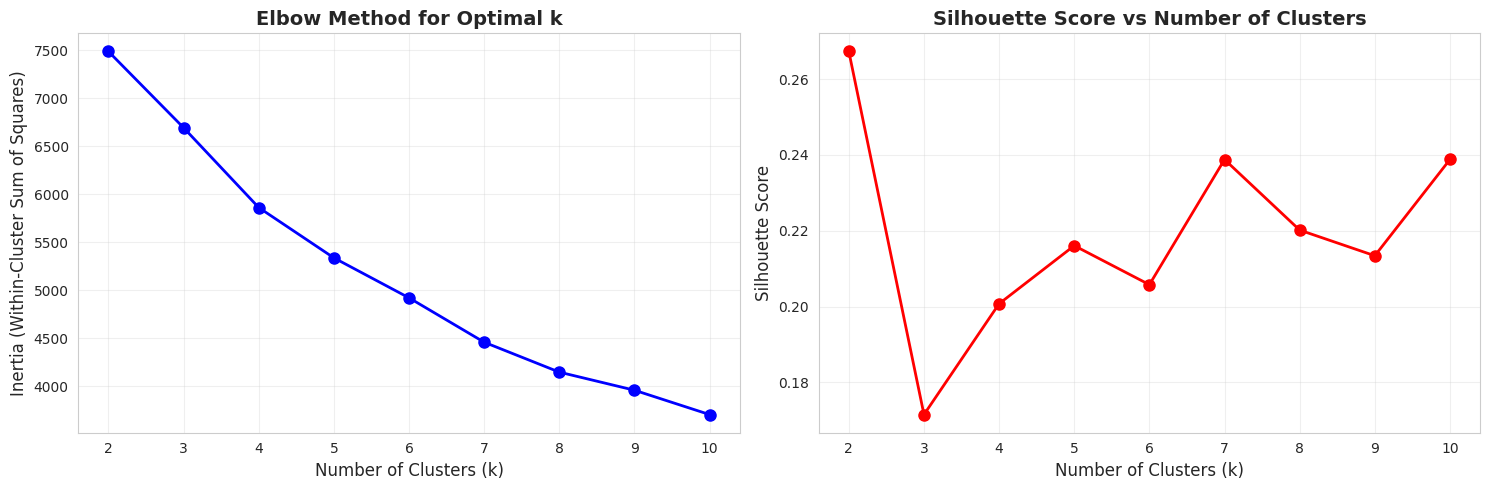

Optimal k based on Silhouette Score: 2


In [42]:
# Prepare academic performance data
X_academic, scaler_academic = prepare_data(df_processed, academic_features)

print("="*80)
print("SCENARIO 1: ACADEMIC PERFORMANCE CLUSTERING")
print("="*80)
print(f"\nFeatures used: {academic_features}")
print(f"Data shape: {X_academic.shape}")
print(f"Number of students: {X_academic.shape[0]}")

# Find optimal k
print("\n--- Finding Optimal Number of Clusters ---")
optimal_k_academic = plot_elbow_silhouette(X_academic, max_k=10, save_path=f'{SAVE_DIR}/academic_elbow_silhouette.png')

### Method 1: K-Means Clustering
**Why K-Means?**
- Fast and efficient for large datasets
- Works well when clusters are spherical and similar in size
- Easy to interpret cluster centroids as "prototypical students"


--- K-Means Clustering Results ---
Number of clusters: 2
Silhouette Score: 0.2673 (higher is better, range: -1 to 1)
Davies-Bouldin Score: 1.7736 (lower is better)
Calinski-Harabasz Score: 265.89 (higher is better)

Cluster Distribution:
  Cluster 0: 743 students (71.2%)
  Cluster 1: 301 students (28.8%)


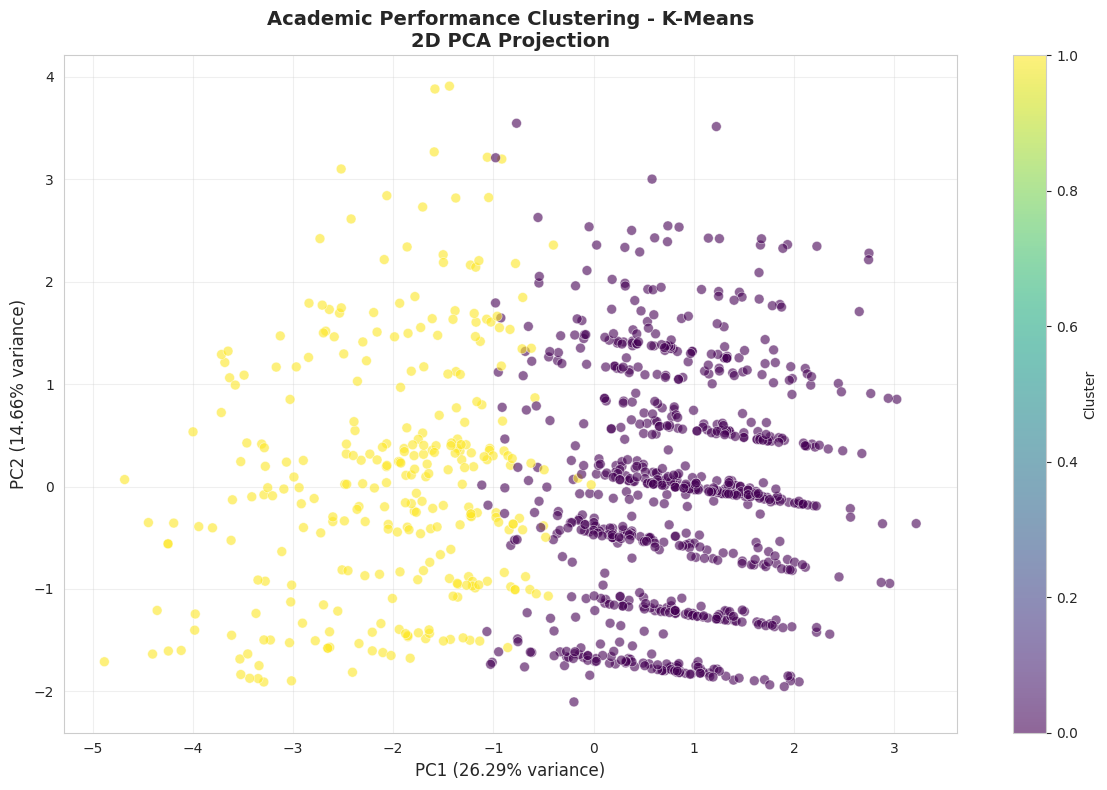

In [43]:
# K-Means Clustering
kmeans_academic = KMeans(n_clusters=optimal_k_academic, random_state=42, n_init=10)
labels_kmeans_academic = kmeans_academic.fit_predict(X_academic)

# Evaluate
sil, db, ch = evaluate_clustering(X_academic, labels_kmeans_academic)

print("\n--- K-Means Clustering Results ---")
print(f"Number of clusters: {optimal_k_academic}")
print(f"Silhouette Score: {sil:.4f} (higher is better, range: -1 to 1)")
print(f"Davies-Bouldin Score: {db:.4f} (lower is better)")
print(f"Calinski-Harabasz Score: {ch:.2f} (higher is better)")

# Cluster distribution
unique, counts = np.unique(labels_kmeans_academic, return_counts=True)
print("\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} students ({count/len(labels_kmeans_academic)*100:.1f}%)")

# Visualize
visualize_clusters_2d(X_academic, labels_kmeans_academic,
                      "Academic Performance Clustering", "K-Means", save_path=f'{SAVE_DIR}/academic_kmeans_pca.png')

In [23]:

# Analyze cluster characteristics
df_academic_clusters = df_processed.copy() # Changed from df.copy() to df_processed.copy()
df_academic_clusters['Cluster_KMeans'] = labels_kmeans_academic

print("\n--- Cluster Characteristics (Mean Values) ---")
cluster_summary = df_academic_clusters.groupby('Cluster_KMeans')[academic_features].mean()
print(cluster_summary.round(2))


--- Cluster Characteristics (Mean Values) ---
                   G1     G2     G3  studytime  failures  schoolsup  famsup  \
Cluster_KMeans                                                                
0               12.48   3.99  13.05       2.05      0.08       0.10    0.62   
1                8.08  14.40   7.12       1.78      0.71       0.14    0.59   

                paid  absences  
Cluster_KMeans                  
0               0.20      3.88  
1               0.23      5.80  


### Method 2: Hierarchical Clustering
**Why Hierarchical?**
- Shows nested relationships between student groups
- Dendrograms reveal the hierarchical structure of performance levels
- Doesn't require pre-specifying number of clusters
- Useful for understanding gradual transitions between performance levels


--- Hierarchical Clustering Results ---


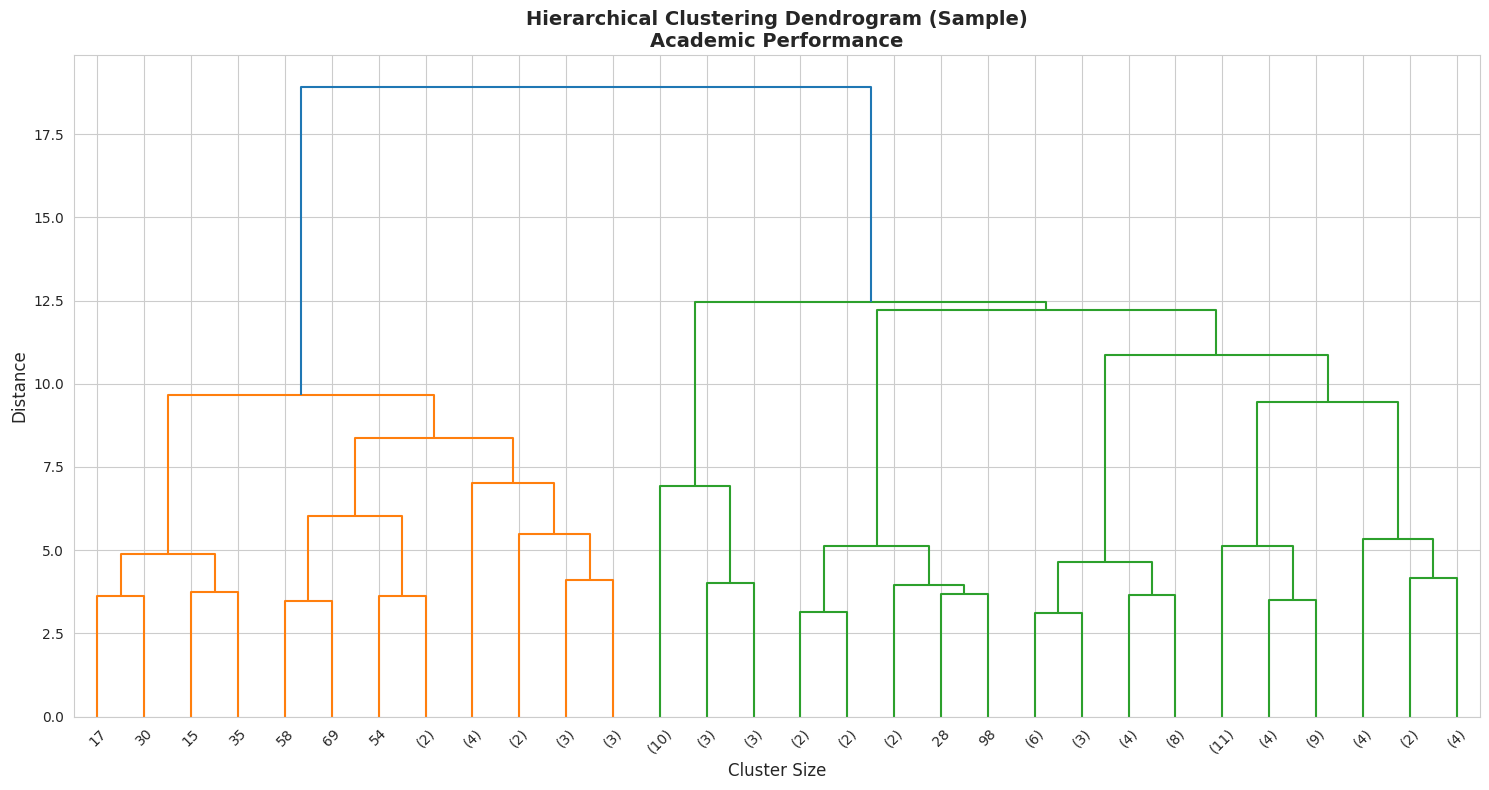

Number of clusters: 2
Silhouette Score: 0.2557
Davies-Bouldin Score: 1.7899
Calinski-Harabasz Score: 235.62

Cluster Distribution:
  Cluster 0: 777 students (74.4%)
  Cluster 1: 267 students (25.6%)


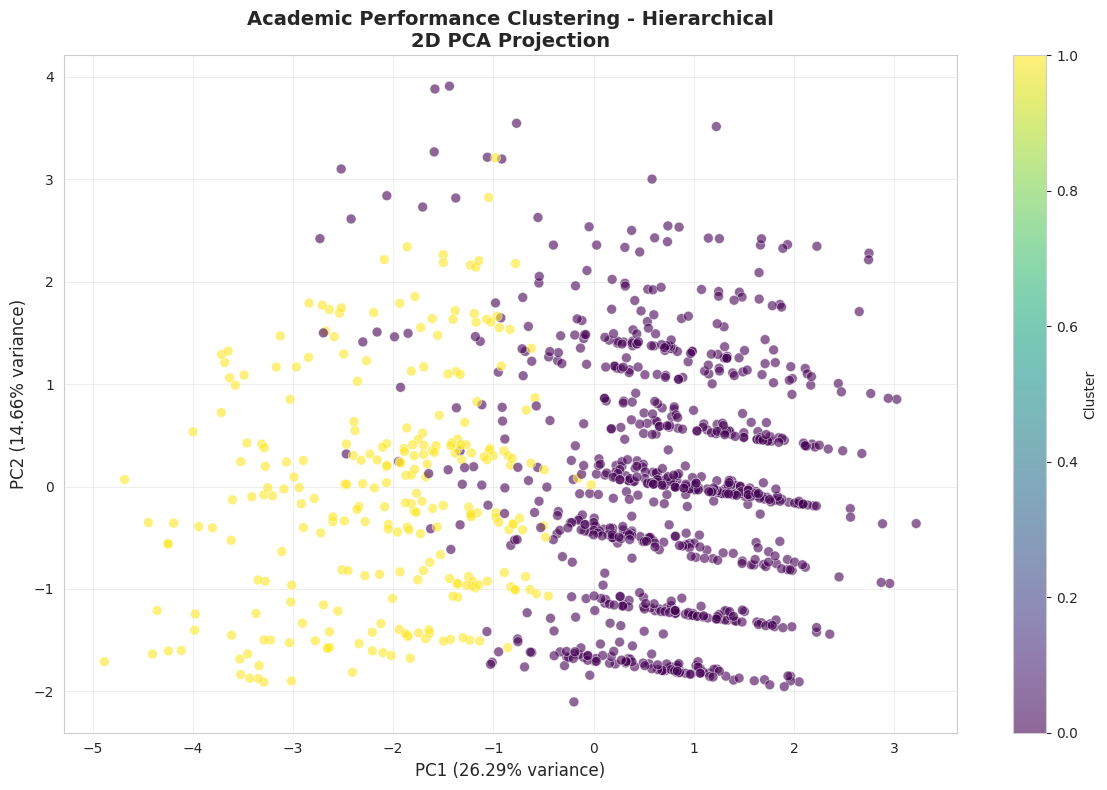

In [44]:
# Hierarchical Clustering with Dendrogram
print("\n--- Hierarchical Clustering Results ---")

# Create linkage matrix (using subset for visualization)
sample_size = min(100, X_academic.shape[0])
sample_indices = np.random.choice(X_academic.shape[0], sample_size, replace=False)
X_sample = X_academic[sample_indices]

linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
fig_dendrogram = plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Sample)\nAcademic Performance',
          fontsize=14, fontweight='bold')
plt.xlabel('Cluster Size', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/academic_hierarchical_dendrogram.png')
plt.show()
plt.close(fig_dendrogram)

# Perform agglomerative clustering on full dataset
hierarchical_academic = AgglomerativeClustering(n_clusters=optimal_k_academic, linkage='ward')
labels_hierarchical_academic = hierarchical_academic.fit_predict(X_academic)

# Evaluate
sil, db, ch = evaluate_clustering(X_academic, labels_hierarchical_academic)
print(f"Number of clusters: {optimal_k_academic}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")
print(f"Calinski-Harabasz Score: {ch:.2f}")

# Cluster distribution
unique, counts = np.unique(labels_hierarchical_academic, return_counts=True)
print("\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} students ({count/len(labels_hierarchical_academic)*100:.1f}%)")

# Visualize
visualize_clusters_2d(X_academic, labels_hierarchical_academic,
                      "Academic Performance Clustering", "Hierarchical", save_path=f'{SAVE_DIR}/academic_hierarchical_pca.png')

### Method 3: DBSCAN (Density-Based Clustering)
**Why DBSCAN?**
- Identifies outliers/anomalous students who don't fit typical patterns
- Finds clusters of arbitrary shapes
- Doesn't require specifying number of clusters
- Useful for detecting students with unusual performance profiles


--- DBSCAN Clustering Results ---


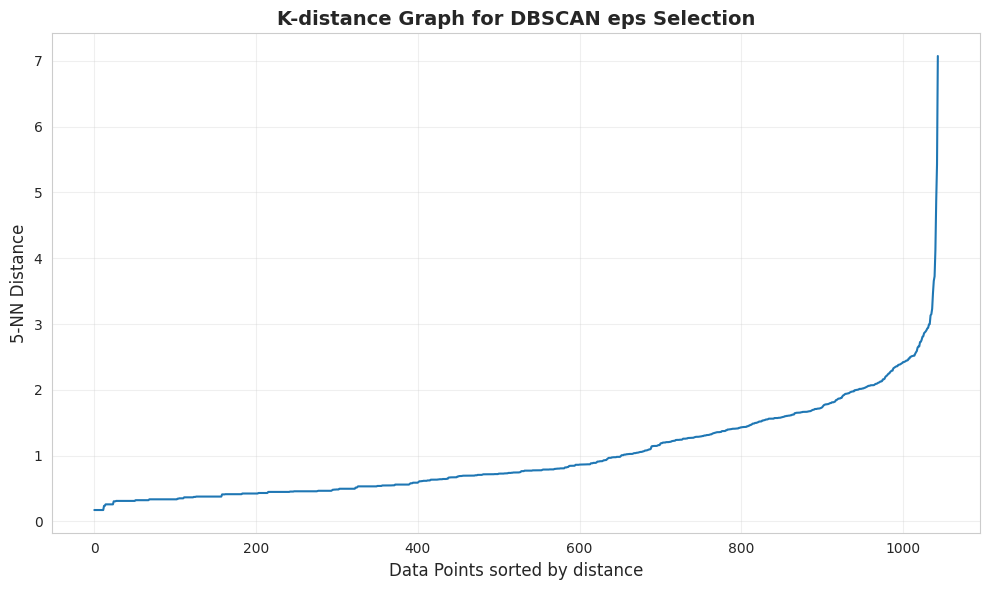

Estimated eps: 2.3510
Number of clusters: 6
Number of outliers: 18 (1.7%)
Silhouette Score: 0.1565 (excluding outliers)
Davies-Bouldin Score: 1.4333
Calinski-Harabasz Score: 80.54

Cluster Distribution:
  Outliers: 18 students (1.7%)
  Cluster 0: 89 students (8.5%)
  Cluster 1: 728 students (69.7%)
  Cluster 2: 136 students (13.0%)
  Cluster 3: 49 students (4.7%)
  Cluster 4: 12 students (1.1%)
  Cluster 5: 12 students (1.1%)


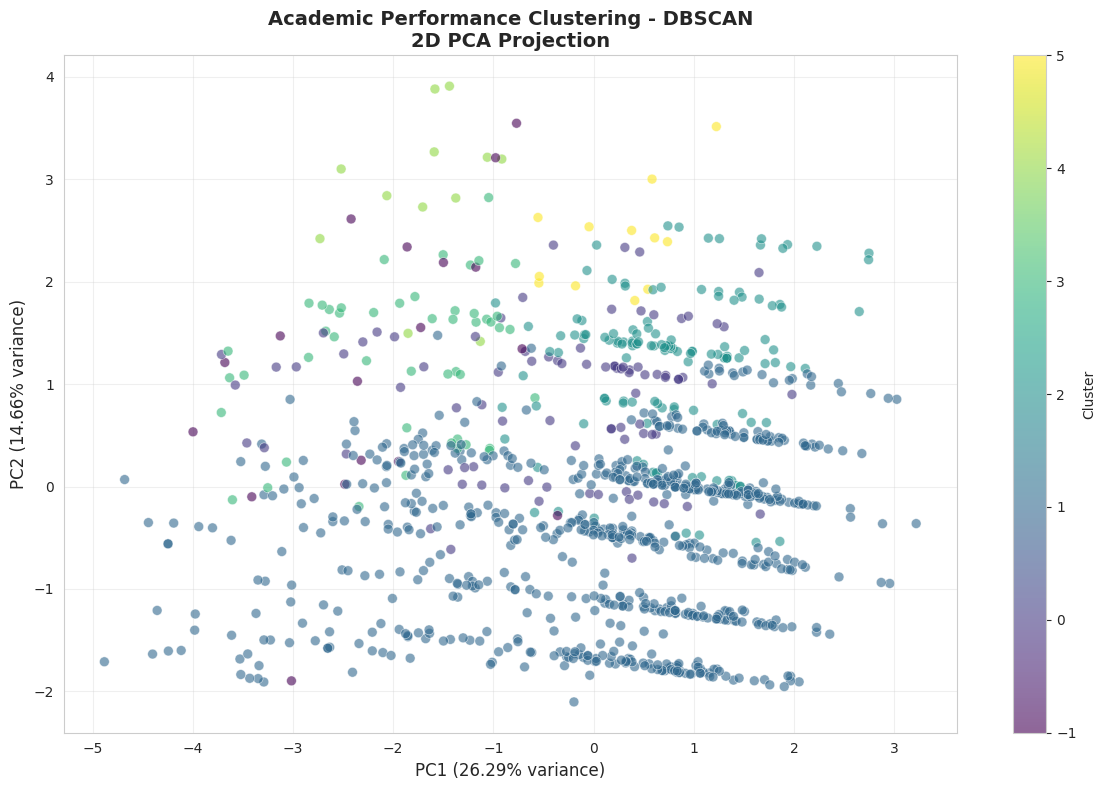

In [45]:
# DBSCAN Clustering
print("\n--- DBSCAN Clustering Results ---")

# Find optimal eps using k-distance graph
from sklearn.neighbors import NearestNeighbors
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_academic)
distances, indices = nbrs.kneighbors(X_academic)
distances = np.sort(distances[:, k-1], axis=0)

fig_k_distance = plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.ylabel(f'{k}-NN Distance', fontsize=12)
plt.title('K-distance Graph for DBSCAN eps Selection', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/academic_dbscan_k_distance.png')
plt.show()
plt.close(fig_k_distance)

# Use DBSCAN with tuned parameters
eps_value = np.percentile(distances, 95)  # Use 95th percentile as eps
dbscan_academic = DBSCAN(eps=eps_value, min_samples=5)
labels_dbscan_academic = dbscan_academic.fit_predict(X_academic)

n_clusters = len(set(labels_dbscan_academic)) - (1 if -1 in labels_dbscan_academic else 0)
n_noise = list(labels_dbscan_academic).count(-1)

print(f"Estimated eps: {eps_value:.4f}")
print(f"Number of clusters: {n_clusters}")
print(f"Number of outliers: {n_noise} ({n_noise/len(labels_dbscan_academic)*100:.1f}%)")

if n_clusters >= 2:
    # Evaluate (excluding noise points)
    mask = labels_dbscan_academic != -1
    if sum(mask) > 0:
        sil, db, ch = evaluate_clustering(X_academic[mask], labels_dbscan_academic[mask])
        print(f"Silhouette Score: {sil:.4f} (excluding outliers)")
        print(f"Davies-Bouldin Score: {db:.4f}")
        print(f"Calinski-Harabasz Score: {ch:.2f}")

# Cluster distribution
unique, counts = np.unique(labels_dbscan_academic, return_counts=True)
print("\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    if cluster == -1:
        print(f"  Outliers: {count} students ({count/len(labels_dbscan_academic)*100:.1f}%)")
    else:
        print(f"  Cluster {cluster}: {count} students ({count/len(labels_dbscan_academic)*100:.1f}%)")

# Visualize
visualize_clusters_2d(X_academic, labels_dbscan_academic,
                      "Academic Performance Clustering", "DBSCAN", save_path=f'{SAVE_DIR}/academic_dbscan_pca.png')

### Method 4: Gaussian Mixture Models (GMM)
**Why GMM?**
- Provides probabilistic cluster assignments (soft clustering)
- Can model elliptical clusters of varying sizes
- Gives probability of belonging to each cluster
- Useful for understanding students at cluster boundaries


--- Gaussian Mixture Model Clustering Results ---
Number of clusters: 2
Silhouette Score: 0.1475
Davies-Bouldin Score: 2.4589
Calinski-Harabasz Score: 139.11
BIC Score: 11615.17 (lower is better)
AIC Score: 11075.53 (lower is better)

Cluster Distribution:
  Cluster 0: 404 students (38.7%)
  Cluster 1: 640 students (61.3%)


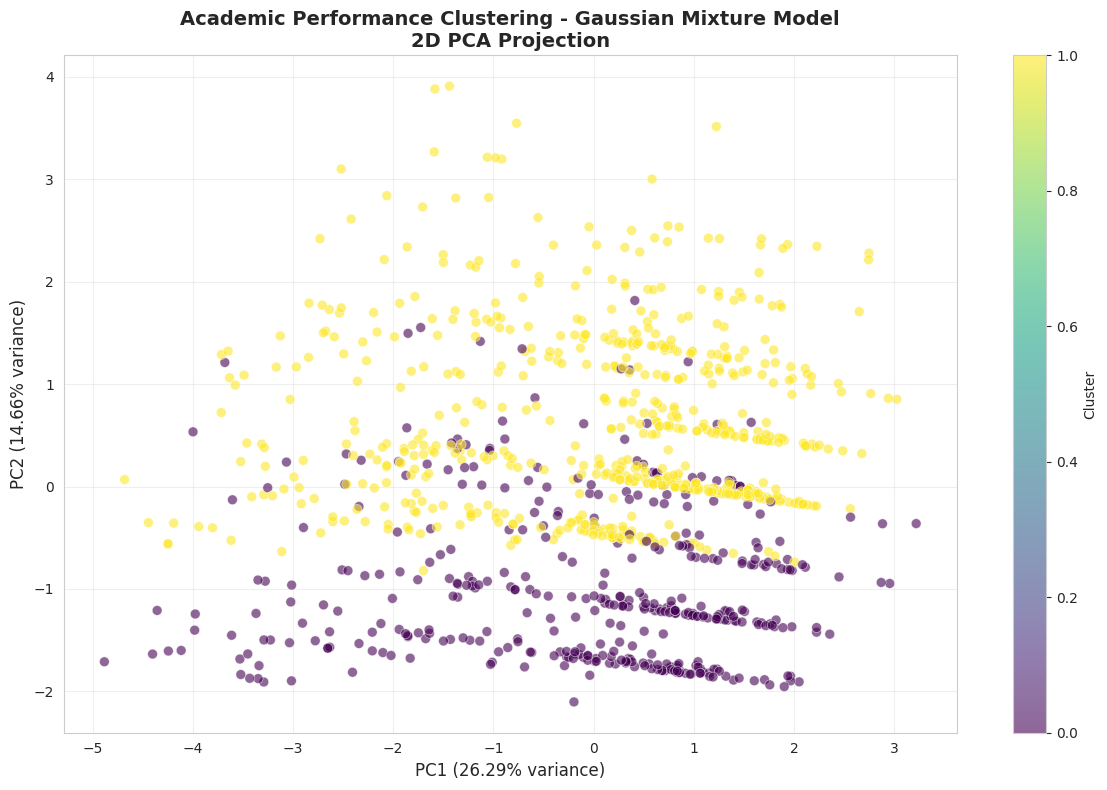


--- Sample Student Cluster Probabilities ---
Student 1: Cluster 0=1.000 Cluster 1=0.000 
Student 2: Cluster 0=0.000 Cluster 1=1.000 
Student 3: Cluster 0=1.000 Cluster 1=0.000 
Student 4: Cluster 0=0.000 Cluster 1=1.000 
Student 5: Cluster 0=0.000 Cluster 1=1.000 


In [46]:
# Gaussian Mixture Model Clustering
print("\n--- Gaussian Mixture Model Clustering Results ---")

gmm_academic = GaussianMixture(n_components=optimal_k_academic, random_state=42,
                               covariance_type='full')
labels_gmm_academic = gmm_academic.fit_predict(X_academic)
proba_gmm_academic = gmm_academic.predict_proba(X_academic)

# Evaluate
sil, db, ch = evaluate_clustering(X_academic, labels_gmm_academic)
print(f"Number of clusters: {optimal_k_academic}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")
print(f"Calinski-Harabasz Score: {ch:.2f}")
print(f"BIC Score: {gmm_academic.bic(X_academic):.2f} (lower is better)")
print(f"AIC Score: {gmm_academic.aic(X_academic):.2f} (lower is better)")

# Cluster distribution
unique, counts = np.unique(labels_gmm_academic, return_counts=True)
print("\nCluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} students ({count/len(labels_gmm_academic)*100:.1f}%)")

# Visualize
visualize_clusters_2d(X_academic, labels_gmm_academic,
                      "Academic Performance Clustering", "Gaussian Mixture Model", save_path=f'{SAVE_DIR}/academic_gmm_pca.png')

# Show probability distribution for a sample of students
print("\n--- Sample Student Cluster Probabilities ---")
sample_probs = proba_gmm_academic[:5]
for i, probs in enumerate(sample_probs):
    print(f"Student {i+1}: ", end="")
    for j, prob in enumerate(probs):
        print(f"Cluster {j}={prob:.3f} ", end="")
    print()

### Comparison of All Methods - Academic Performance

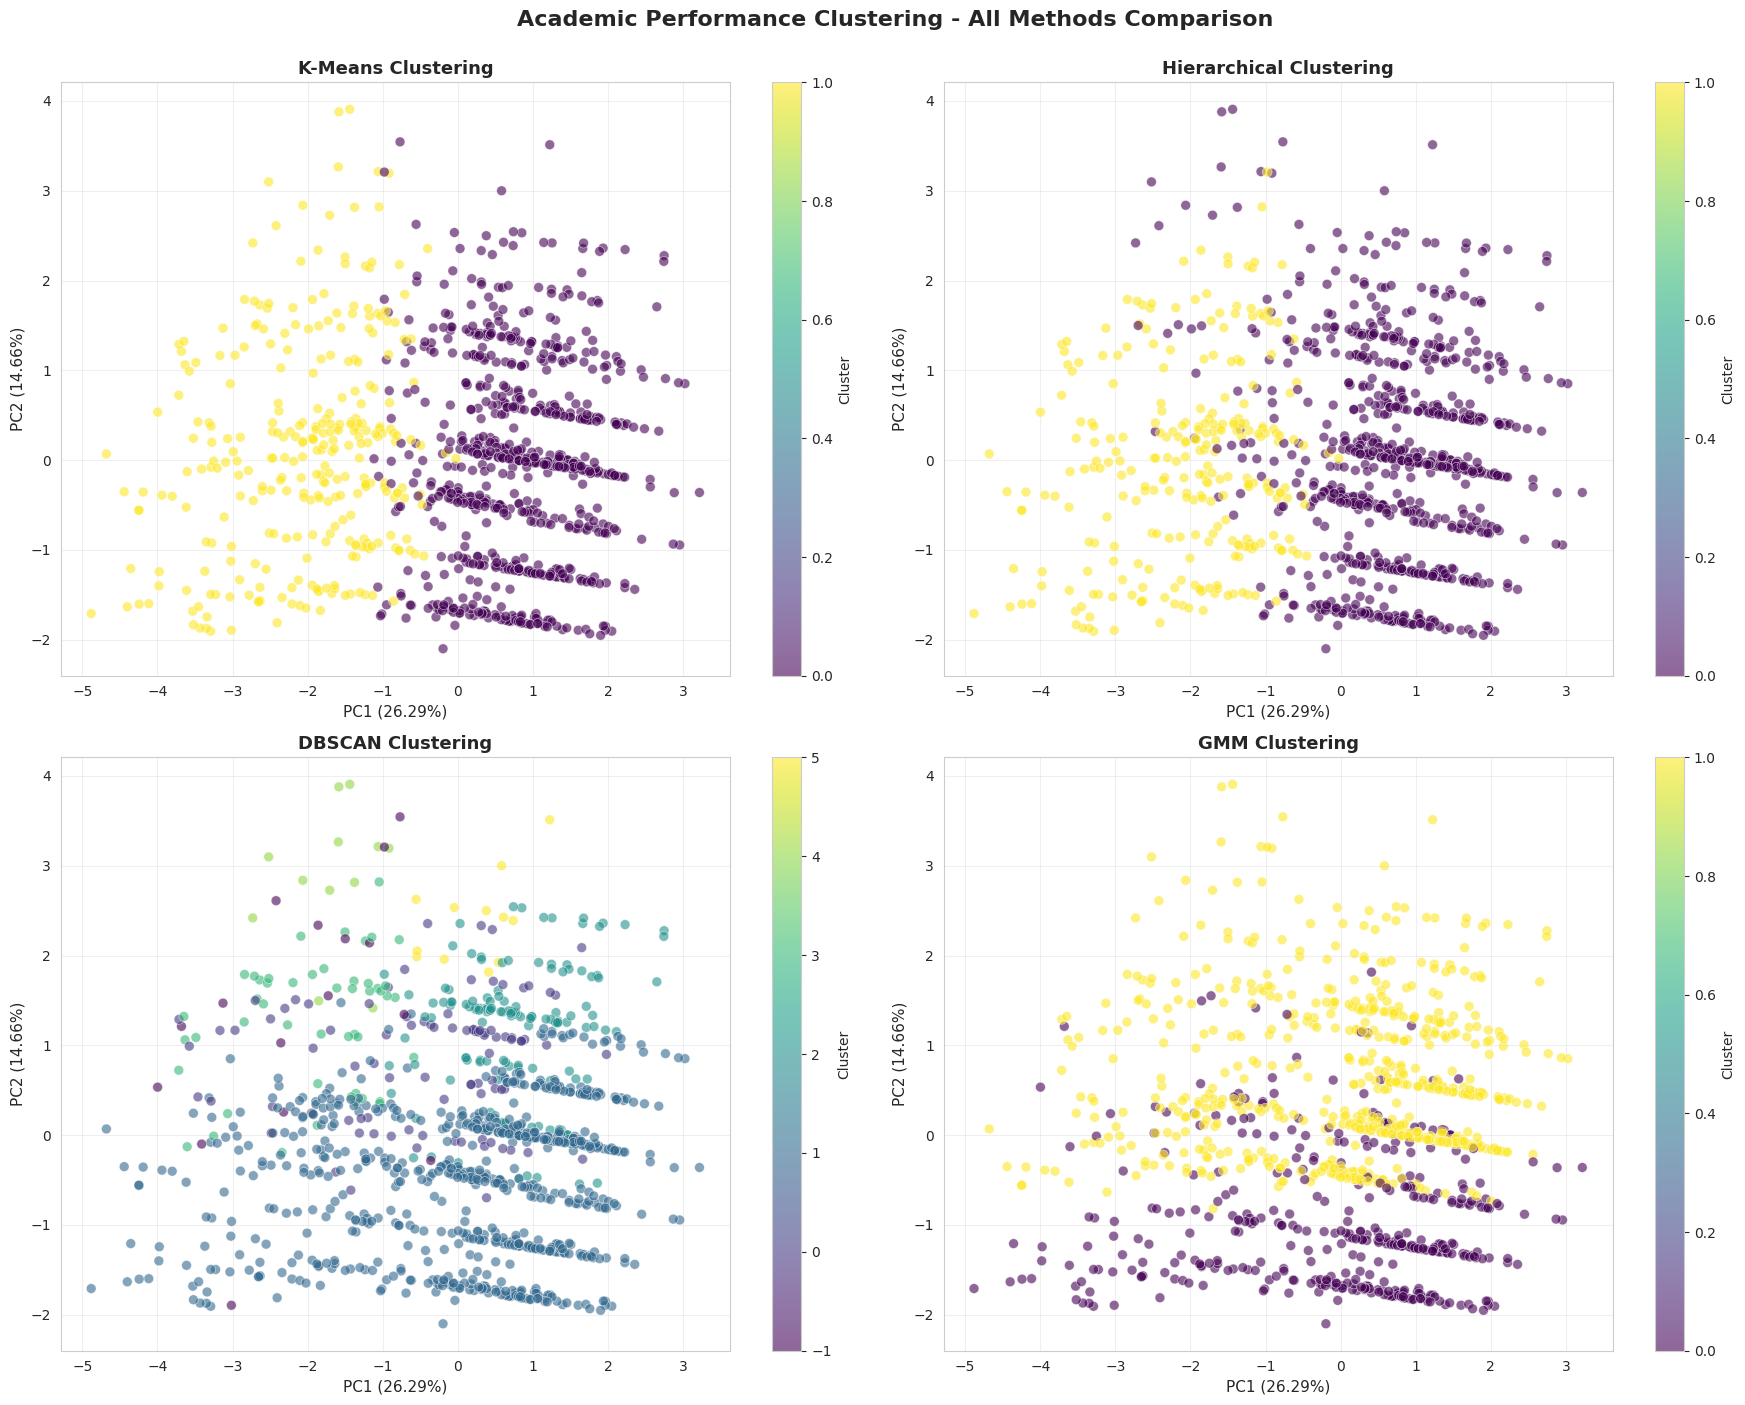


ACADEMIC PERFORMANCE CLUSTERING - METHODS COMPARISON
      Method  Clusters  Outliers Silhouette Davies-Bouldin Calinski-Harabasz
     K-Means         2         0     0.2673         1.7736            265.89
Hierarchical         2         0     0.2557         1.7899            235.62
      DBSCAN         6        18     0.1565         1.4333             80.54
         GMM         2         0     0.1475         2.4589            139.11


In [47]:
# Compare all methods for Academic Performance
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

all_labels = [
    (labels_kmeans_academic, "K-Means"),
    (labels_hierarchical_academic, "Hierarchical"),
    (labels_dbscan_academic, "DBSCAN"),
    (labels_gmm_academic, "GMM")
]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_academic)

for idx, (labels, method) in enumerate(all_labels):
    ax = axes[idx // 2, idx % 2]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis',
                        s=50, alpha=0.6, edgecolors='w', linewidth=0.5)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
    ax.set_title(f'{method} Clustering', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('Academic Performance Clustering - All Methods Comparison',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/academic_comparison_pca.png')
plt.show()
plt.close(fig)

# Create comparison metrics table
comparison_data = []

for labels, method in all_labels:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1) if -1 in labels else 0

    if n_clusters >= 2:
        mask = labels != -1
        if sum(mask) > 0:
            sil, db, ch = evaluate_clustering(X_academic[mask], labels[mask])
        else:
            sil, db, ch = None, None, None
    else:
        sil, db, ch = None, None, None

    comparison_data.append({
        'Method': method,
        'Clusters': n_clusters,
        'Outliers': n_noise,
        'Silhouette': f'{sil:.4f}' if sil else 'N/A',
        'Davies-Bouldin': f'{db:.4f}' if db else 'N/A',
        'Calinski-Harabasz': f'{ch:.2f}' if ch else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("ACADEMIC PERFORMANCE CLUSTERING - METHODS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

---
# SCENARIO 2: BEHAVIORAL PATTERN CLUSTERING
---

## Why Behavioral Pattern Clustering?

Behavioral clustering reveals student lifestyle patterns:
- **Identify at-risk behaviors** (excessive alcohol consumption, frequent absences)
- **Understand work-life balance** across student groups
- **Design targeted wellness programs** and interventions
- **Correlate lifestyle choices** with academic outcomes
- **Create peer support groups** with similar lifestyles

SCENARIO 2: BEHAVIORAL PATTERN CLUSTERING

Features used: ['goout', 'Dalc', 'Walc', 'freetime', 'romantic', 'activities', 'absences', 'health', 'famrel']
Data shape: (1044, 9)

--- Finding Optimal Number of Clusters ---


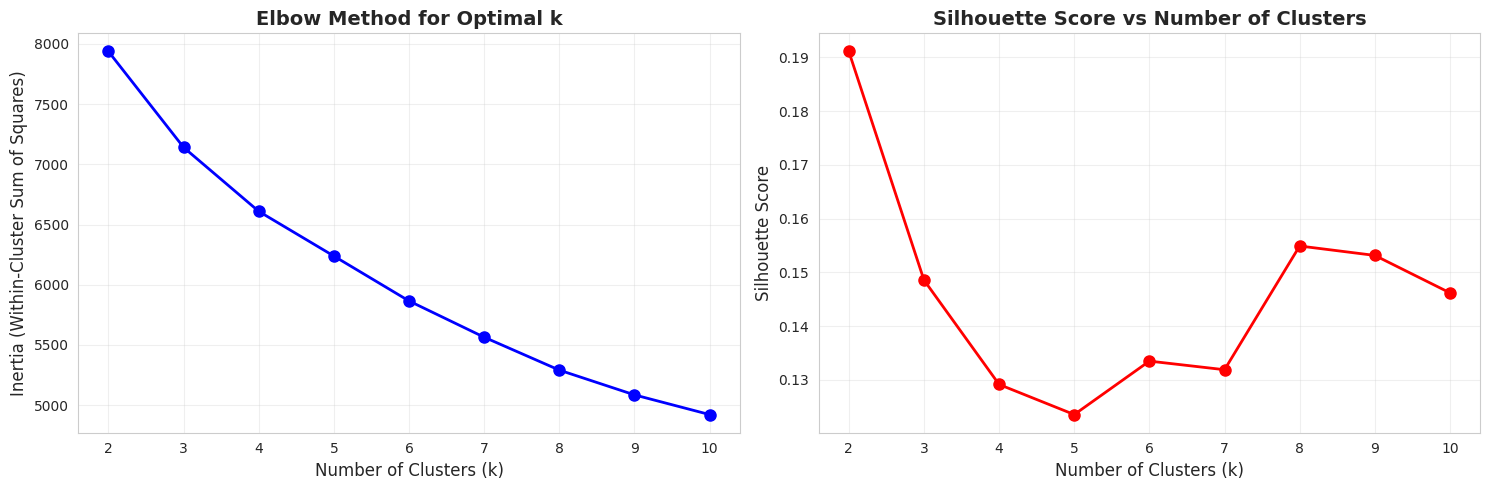

Optimal k based on Silhouette Score: 2

Applying All Clustering Methods...

✓ K-Means completed
✓ Hierarchical completed
✓ DBSCAN completed
✓ GMM completed


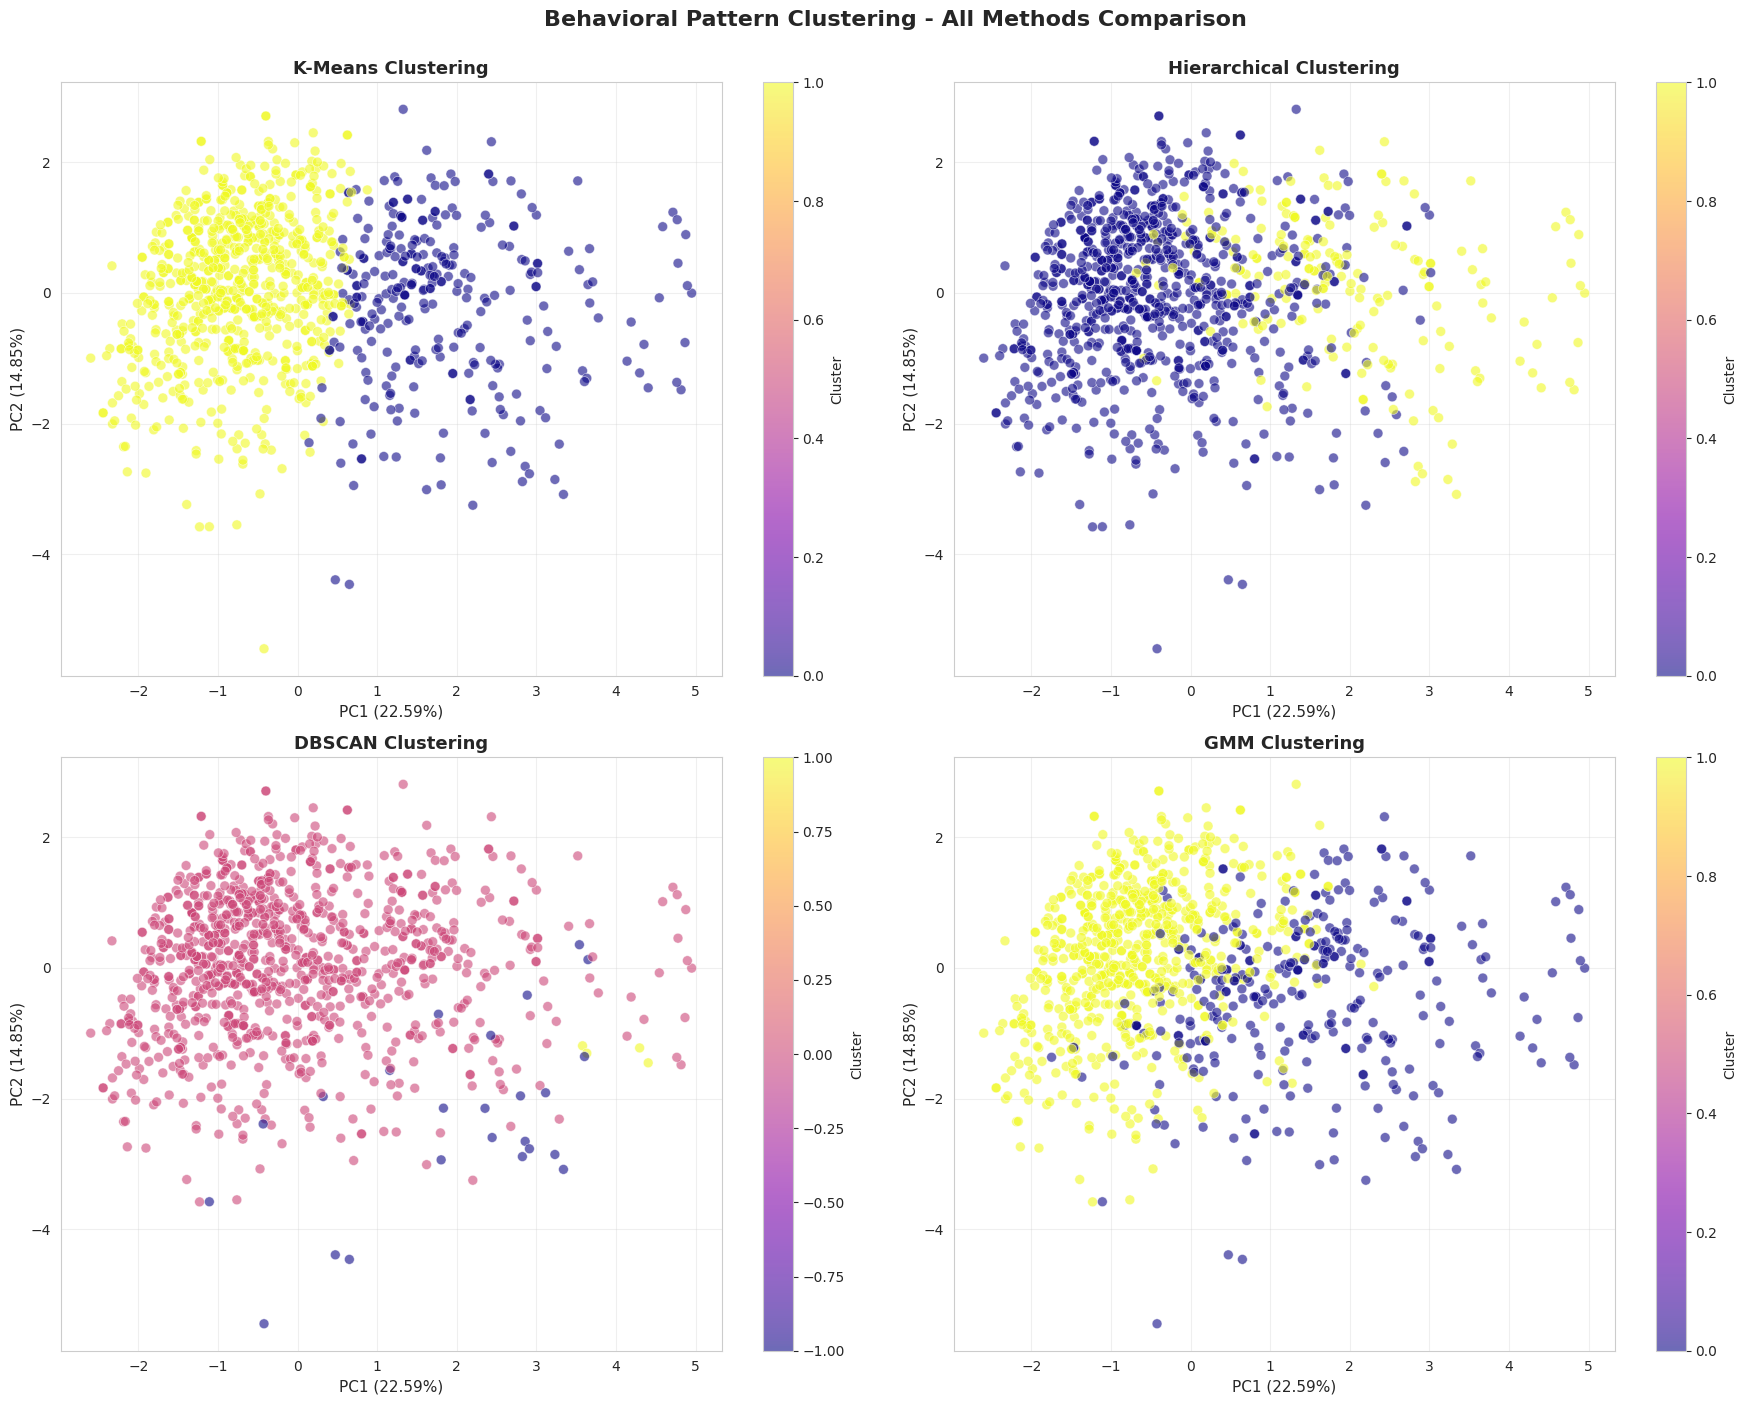


BEHAVIORAL PATTERN CLUSTERING - METHODS COMPARISON
      Method  Clusters  Outliers Silhouette Davies-Bouldin Calinski-Harabasz
     K-Means         2         0     0.1911         2.0885            191.45
Hierarchical         2         0     0.1551         2.2139            121.23
      DBSCAN         2        24     0.3166         0.7460             12.71
         GMM         2         0     0.1580         2.3800            152.26

--- K-Means Cluster Characteristics (Mean Values) ---
         goout  Dalc  Walc  freetime  romantic  activities  absences  health  \
Cluster                                                                        
0         4.05  2.43  3.84      3.63      0.33        0.55      6.53    3.77   
1         2.80  1.12  1.66      3.03      0.37        0.47      3.60    3.45   

         famrel  
Cluster          
0          3.81  
1          3.99  


In [48]:
# Prepare behavioral data and apply all 4 clustering methods
X_behavioral, scaler_behavioral = prepare_data(df_processed, behavioral_features)

print("="*80)
print("SCENARIO 2: BEHAVIORAL PATTERN CLUSTERING")
print("="*80)
print(f"\nFeatures used: {behavioral_features}")
print(f"Data shape: {X_behavioral.shape}")

# Find optimal k
print("\n--- Finding Optimal Number of Clusters ---")
optimal_k_behavioral = plot_elbow_silhouette(X_behavioral, max_k=10, save_path=f'{SAVE_DIR}/behavioral_elbow_silhouette.png')

# Apply all 4 methods
print("\n" + "="*80)
print("Applying All Clustering Methods...")
print("="*80)

# 1. K-Means
kmeans_behavioral = KMeans(n_clusters=optimal_k_behavioral, random_state=42, n_init=10)
labels_kmeans_behavioral = kmeans_behavioral.fit_predict(X_behavioral)
print("\n✓ K-Means completed")

# 2. Hierarchical
hierarchical_behavioral = AgglomerativeClustering(n_clusters=optimal_k_behavioral, linkage='ward')
labels_hierarchical_behavioral = hierarchical_behavioral.fit_predict(X_behavioral)
print("✓ Hierarchical completed")

# 3. DBSCAN
nbrs = NearestNeighbors(n_neighbors=5).fit(X_behavioral)
distances, _ = nbrs.kneighbors(X_behavioral)
distances = np.sort(distances[:, 4], axis=0)
eps_behavioral = np.percentile(distances, 95)
dbscan_behavioral = DBSCAN(eps=eps_behavioral, min_samples=5)
labels_dbscan_behavioral = dbscan_behavioral.fit_predict(X_behavioral)
print("✓ DBSCAN completed")

# 4. GMM
gmm_behavioral = GaussianMixture(n_components=optimal_k_behavioral, random_state=42)
labels_gmm_behavioral = gmm_behavioral.fit_predict(X_behavioral)
print("✓ GMM completed")

# Visualize all methods
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

all_labels_behavioral = [
    (labels_kmeans_behavioral, "K-Means"),
    (labels_hierarchical_behavioral, "Hierarchical"),
    (labels_dbscan_behavioral, "DBSCAN"),
    (labels_gmm_behavioral, "GMM")
]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_behavioral)

for idx, (labels, method) in enumerate(all_labels_behavioral):
    ax = axes[idx // 2, idx % 2]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='plasma',
                        s=50, alpha=0.6, edgecolors='w', linewidth=0.5)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
    ax.set_title(f'{method} Clustering', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('Behavioral Pattern Clustering - All Methods Comparison',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/behavioral_comparison_pca.png')
plt.show()
plt.close(fig)

# Create comparison table
comparison_data = []
for labels, method in all_labels_behavioral:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1) if -1 in labels else 0

    if n_clusters >= 2:
        mask = labels != -1
        if sum(mask) > 0:
            sil, db, ch = evaluate_clustering(X_behavioral[mask], labels[mask])
        else:
            sil, db, ch = None, None, None
    else:
        sil, db, ch = None, None, None

    comparison_data.append({
        'Method': method,
        'Clusters': n_clusters,
        'Outliers': n_noise,
        'Silhouette': f'{sil:.4f}' if sil else 'N/A',
        'Davies-Bouldin': f'{db:.4f}' if db else 'N/A',
        'Calinski-Harabasz': f'{ch:.2f}' if ch else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("BEHAVIORAL PATTERN CLUSTERING - METHODS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Analyze cluster characteristics for best method (K-Means)
df_behavioral_clusters = df_processed.copy()
df_behavioral_clusters['Cluster'] = labels_kmeans_behavioral
print("\n--- K-Means Cluster Characteristics (Mean Values) ---")
print(df_behavioral_clusters.groupby('Cluster')[behavioral_features].mean().round(2))

---
# SCENARIO 3: SOCIO-ECONOMIC BACKGROUND CLUSTERING
---

## Why Socio-Economic Background Clustering?

Understanding socio-economic segments helps:
- **Target financial aid** and scholarships effectively
- **Design family engagement programs** for different backgrounds
- **Address educational equity** issues
- **Understand parental support** patterns and their impact
- **Create inclusive policies** that consider diverse backgrounds

SCENARIO 3: SOCIO-ECONOMIC BACKGROUND CLUSTERING

Features used: ['Medu', 'Fedu', 'traveltime']
Data shape: (1044, 3)

--- Finding Optimal Number of Clusters ---


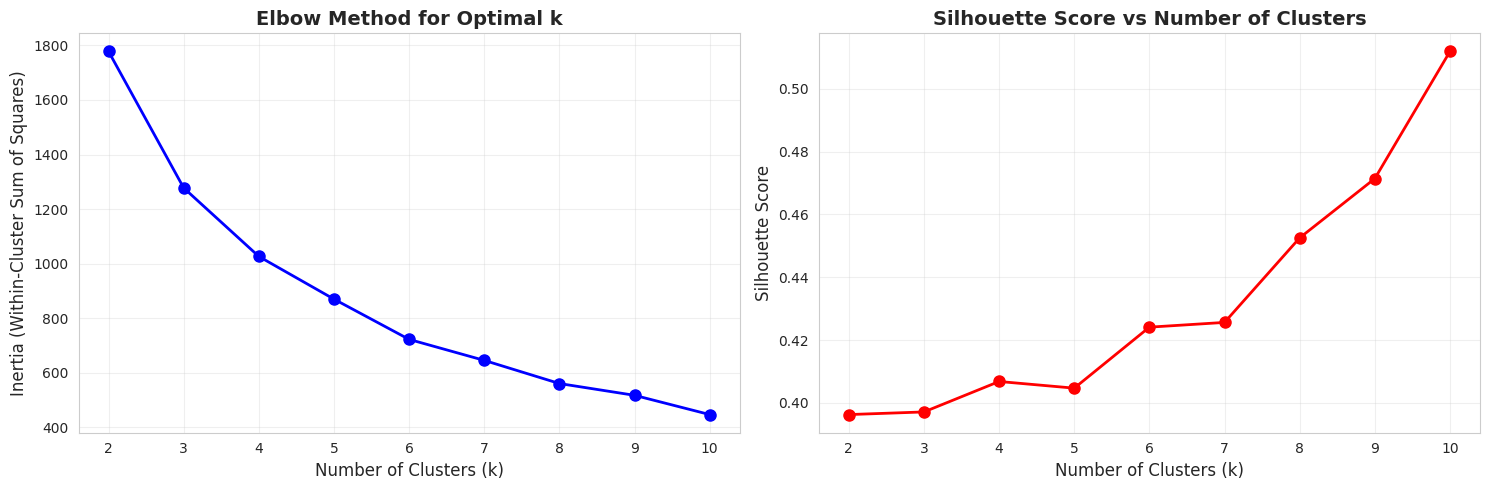

Optimal k based on Silhouette Score: 10

Applying All Clustering Methods...

✓ K-Means completed
✓ Hierarchical completed


InvalidParameterError: The 'eps' parameter of DBSCAN must be a float in the range (0.0, inf). Got np.float64(0.0) instead.

In [49]:
# Prepare socio-economic data and apply all 4 clustering methods
X_socioeconomic, scaler_socioeconomic = prepare_data(df_processed, socioeconomic_features)

print("="*80)
print("SCENARIO 3: SOCIO-ECONOMIC BACKGROUND CLUSTERING")
print("="*80)
print(f"\nFeatures used: {socioeconomic_features}")
print(f"Data shape: {X_socioeconomic.shape}")

# Find optimal k
print("\n--- Finding Optimal Number of Clusters ---")
optimal_k_socioeconomic = plot_elbow_silhouette(X_socioeconomic, max_k=10, save_path=f'{SAVE_DIR}/socioeconomic_elbow_silhouette.png')

# Apply all 4 methods
print("\n" + "="*80)
print("Applying All Clustering Methods...")
print("="*80)

# 1. K-Means
kmeans_socioeconomic = KMeans(n_clusters=optimal_k_socioeconomic, random_state=42, n_init=10)
labels_kmeans_socioeconomic = kmeans_socioeconomic.fit_predict(X_socioeconomic)
print("\n✓ K-Means completed")

# 2. Hierarchical
hierarchical_socioeconomic = AgglomerativeClustering(n_clusters=optimal_k_socioeconomic, linkage='ward')
labels_hierarchical_socioeconomic = hierarchical_socioeconomic.fit_predict(X_socioeconomic)
print("✓ Hierarchical completed")

# 3. DBSCAN
nbrs = NearestNeighbors(n_neighbors=5).fit(X_socioeconomic)
distances, _ = nbrs.kneighbors(X_socioeconomic)
distances = np.sort(distances[:, 4], axis=0)
eps_socioeconomic = np.percentile(distances, 95)
dbscan_socioeconomic = DBSCAN(eps=eps_socioeconomic, min_samples=5)
labels_dbscan_socioeconomic = dbscan_socioeconomic.fit_predict(X_socioeconomic)
print("✓ DBSCAN completed")

# 4. GMM
gmm_socioeconomic = GaussianMixture(n_components=optimal_k_socioeconomic, random_state=42)
labels_gmm_socioeconomic = gmm_socioeconomic.fit_predict(X_socioeconomic)
print("✓ GMM completed")

# Visualize all methods
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

all_labels_socioeconomic = [
    (labels_kmeans_socioeconomic, "K-Means"),
    (labels_hierarchical_socioeconomic, "Hierarchical"),
    (labels_dbscan_socioeconomic, "DBSCAN"),
    (labels_gmm_socioeconomic, "GMM")
]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_socioeconomic)

for idx, (labels, method) in enumerate(all_labels_socioeconomic):
    ax = axes[idx // 2, idx % 2]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='coolwarm',
                        s=50, alpha=0.6, edgecolors='w', linewidth=0.5)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
    ax.set_title(f'{method} Clustering', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('Socio-Economic Background Clustering - All Methods Comparison',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/socioeconomic_comparison_pca.png')
plt.show()
plt.close(fig)

# Create comparison table
comparison_data = []
for labels, method in all_labels_socioeconomic:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1) if -1 in labels else 0

    if n_clusters >= 2:
        mask = labels != -1
        if sum(mask) > 0:
            sil, db, ch = evaluate_clustering(X_socioeconomic[mask], labels[mask])
        else:
            sil, db, ch = None, None, None
    else:
        sil, db, ch = None, None, None

    comparison_data.append({
        'Method': method,
        'Clusters': n_clusters,
        'Outliers': n_noise,
        'Silhouette': f'{sil:.4f}' if sil else 'N/A',
        'Davies-Bouldin': f'{db:.4f}' if db else 'N/A',
        'Calinski-Harabasz': f'{ch:.2f}' if ch else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("SOCIO-ECONOMIC BACKGROUND CLUSTERING - METHODS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Analyze cluster characteristics
df_socioeconomic_clusters = df.copy()
df_socioeconomic_clusters['Cluster'] = labels_kmeans_socioeconomic
print("\n--- K-Means Cluster Characteristics (Mean Values) ---")
print(df_socioeconomic_clusters.groupby('Cluster')[['Medu', 'Fedu', 'traveltime']].mean().round(2))

---
# SCENARIO 4: COMPREHENSIVE STUDENT PROFILE CLUSTERING
---

## Why Comprehensive Profile Clustering?

Holistic clustering combines all aspects:
- **Create personalized learning paths** based on complete student profiles
- **Develop comprehensive support strategies** addressing multiple factors
- **Understand complex interactions** between academics, behavior, and background
- **Design targeted interventions** that consider the whole student
- **Segment students for customized** educational experiences

SCENARIO 4: COMPREHENSIVE STUDENT PROFILE CLUSTERING

Features used: 24 features
Data shape: (1044, 24)

--- Finding Optimal Number of Clusters ---


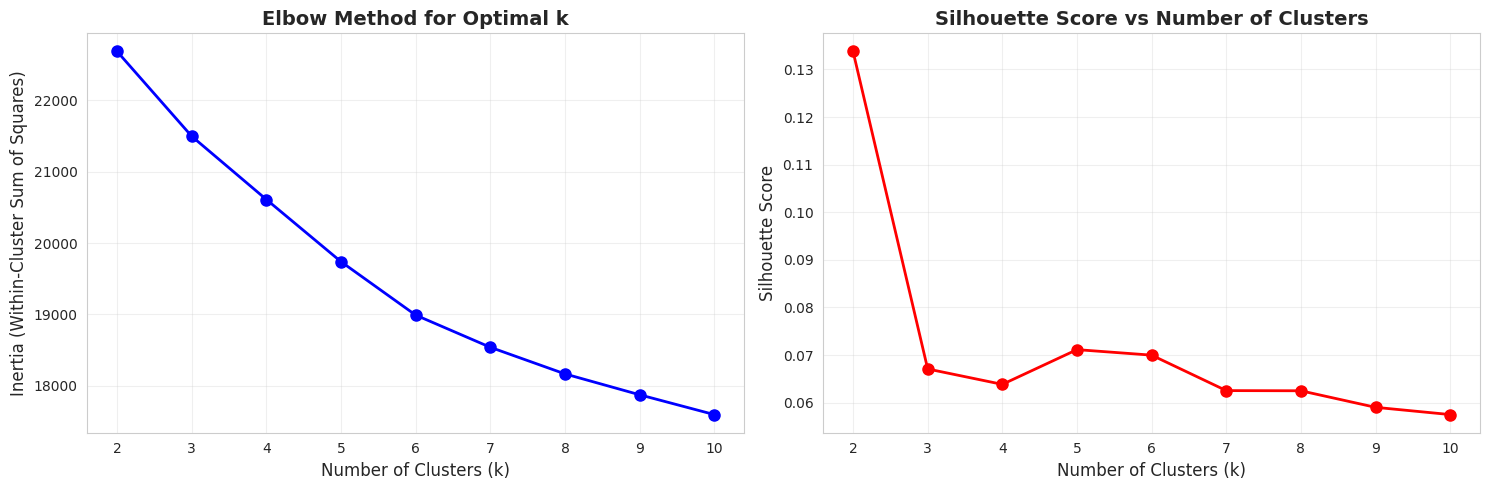

Optimal k based on Silhouette Score: 2

Applying All Clustering Methods...

✓ K-Means completed
✓ Hierarchical completed
✓ DBSCAN completed
✓ GMM completed


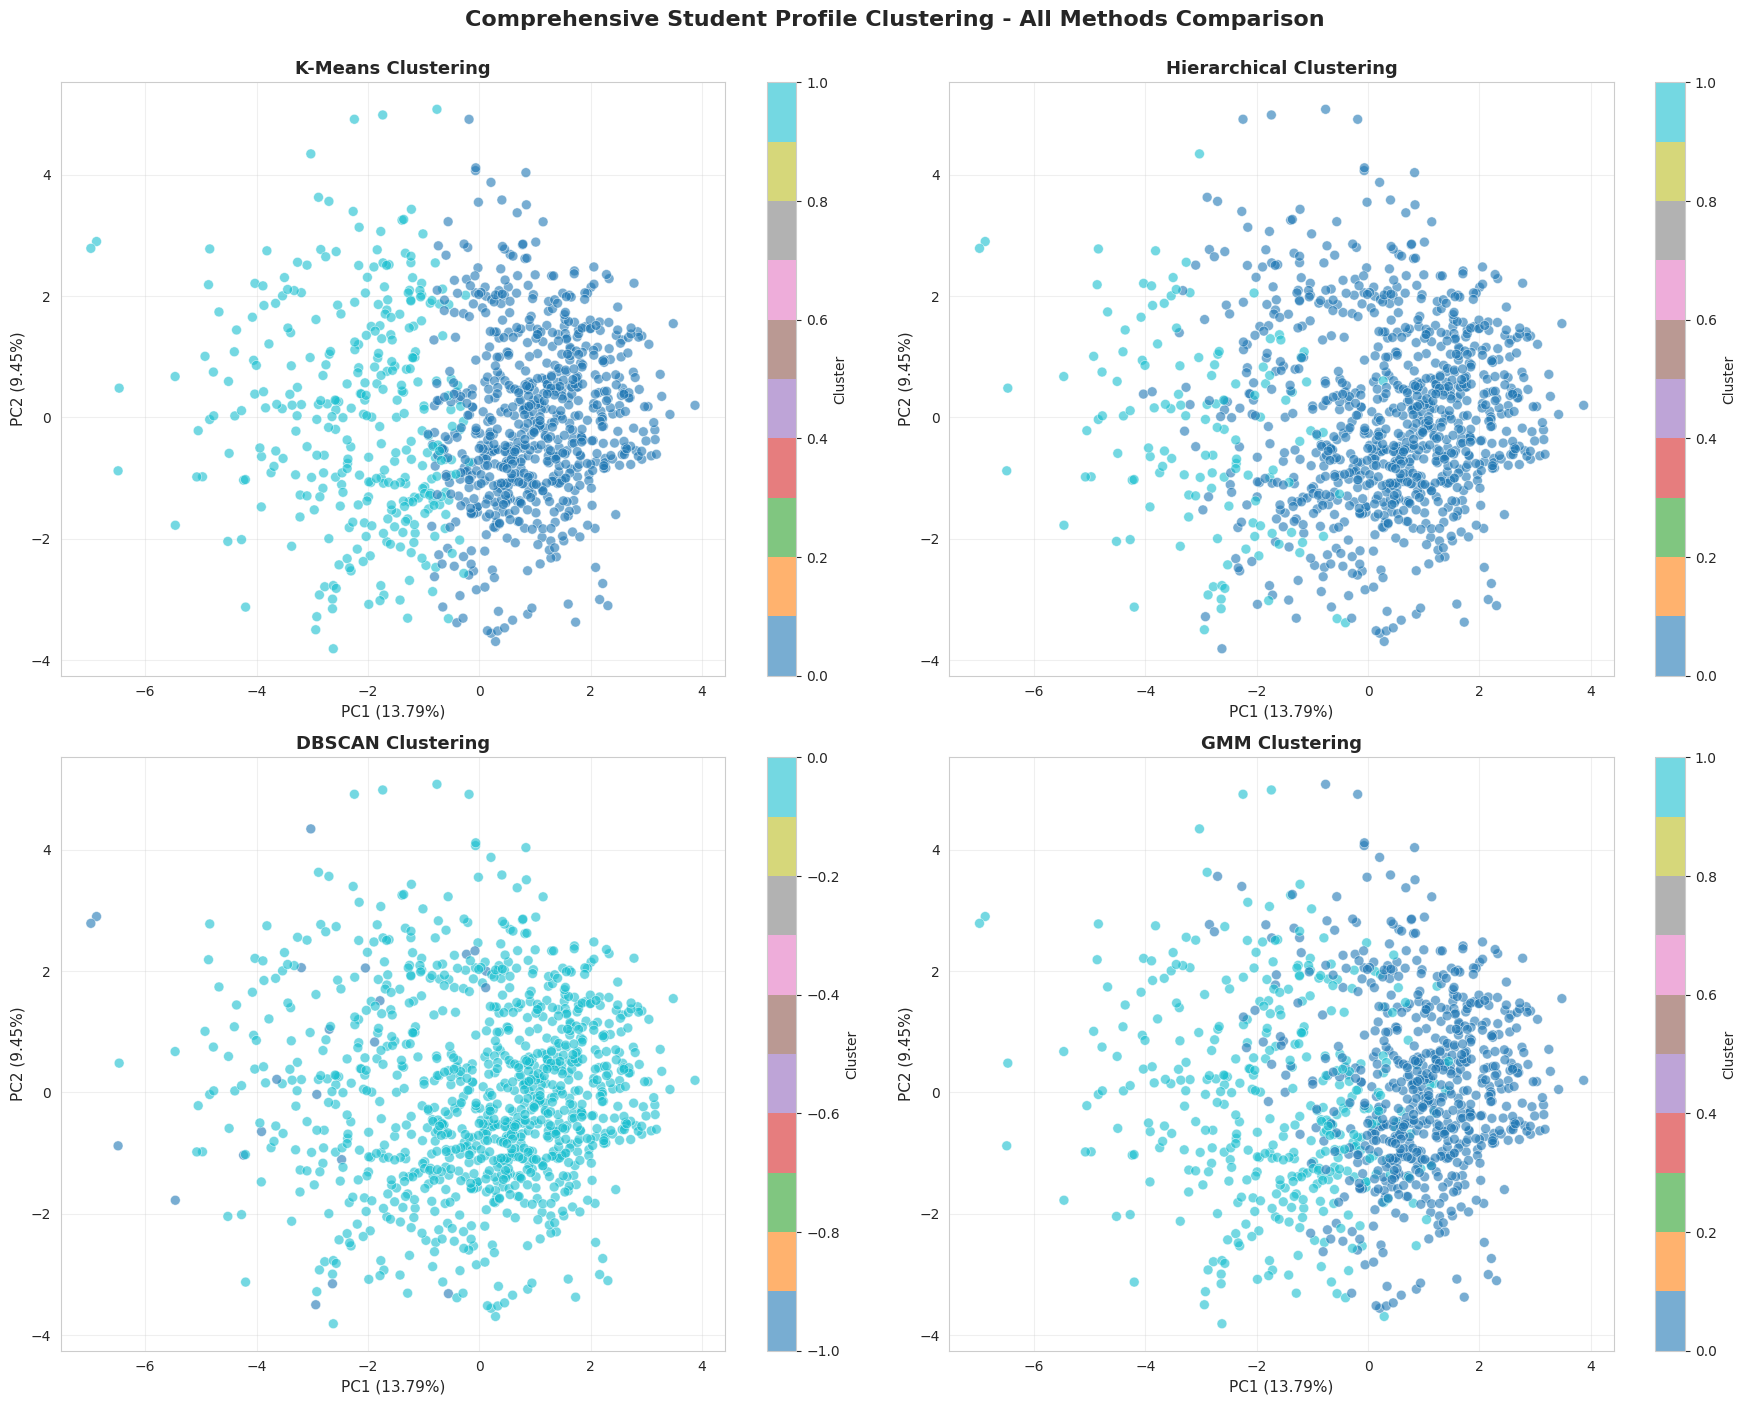


COMPREHENSIVE STUDENT PROFILE CLUSTERING - METHODS COMPARISON
      Method  Clusters  Outliers Silhouette Davies-Bouldin Calinski-Harabasz
     K-Means         2         0     0.1338         2.9312            108.95
Hierarchical         2         0     0.1788         2.5645             76.73
      DBSCAN         1        22        N/A            N/A               N/A
         GMM         2         0     0.1136         3.1787             96.98

--- K-Means Cluster Characteristics (Key Features Mean Values) ---
           age  studytime  failures  absences     G1     G2     G3  goout  \
Cluster                                                                     
0        16.51       2.14      0.06      3.72  12.52   4.80  12.98   3.00   
1        17.18       1.60      0.69      5.96   8.44  11.65   7.87   3.49   

         Dalc  Walc  
Cluster              
0        1.30  2.02  
1        1.91  2.85  


In [50]:
# Prepare comprehensive data and apply all 4 clustering methods
X_comprehensive, scaler_comprehensive = prepare_data(df_processed, comprehensive_features)

print("="*80)
print("SCENARIO 4: COMPREHENSIVE STUDENT PROFILE CLUSTERING")
print("="*80)
print(f"\nFeatures used: {len(comprehensive_features)} features")
print(f"Data shape: {X_comprehensive.shape}")

# Find optimal k
print("\n--- Finding Optimal Number of Clusters ---")
optimal_k_comprehensive = plot_elbow_silhouette(X_comprehensive, max_k=10, save_path=f'{SAVE_DIR}/comprehensive_elbow_silhouette.png')

# Apply all 4 methods
print("\n" + "="*80)
print("Applying All Clustering Methods...")
print("="*80)

# 1. K-Means
kmeans_comprehensive = KMeans(n_clusters=optimal_k_comprehensive, random_state=42, n_init=10)
labels_kmeans_comprehensive = kmeans_comprehensive.fit_predict(X_comprehensive)
print("\n✓ K-Means completed")

# 2. Hierarchical
hierarchical_comprehensive = AgglomerativeClustering(n_clusters=optimal_k_comprehensive, linkage='ward')
labels_hierarchical_comprehensive = hierarchical_comprehensive.fit_predict(X_comprehensive)
print("✓ Hierarchical completed")

# 3. DBSCAN
nbrs = NearestNeighbors(n_neighbors=5).fit(X_comprehensive)
distances, _ = nbrs.kneighbors(X_comprehensive)
distances = np.sort(distances[:, 4], axis=0)
eps_comprehensive = np.percentile(distances, 95)
dbscan_comprehensive = DBSCAN(eps=eps_comprehensive, min_samples=5)
labels_dbscan_comprehensive = dbscan_comprehensive.fit_predict(X_comprehensive)
print("✓ DBSCAN completed")

# 4. GMM
gmm_comprehensive = GaussianMixture(n_components=optimal_k_comprehensive, random_state=42)
labels_gmm_comprehensive = gmm_comprehensive.fit_predict(X_comprehensive)
print("✓ GMM completed")

# Visualize all methods
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

all_labels_comprehensive = [
    (labels_kmeans_comprehensive, "K-Means"),
    (labels_hierarchical_comprehensive, "Hierarchical"),
    (labels_dbscan_comprehensive, "DBSCAN"),
    (labels_gmm_comprehensive, "GMM")
]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_comprehensive)

for idx, (labels, method) in enumerate(all_labels_comprehensive):
    ax = axes[idx // 2, idx % 2]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10',
                        s=50, alpha=0.6, edgecolors='w', linewidth=0.5)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=11)
    ax.set_title(f'{method} Clustering', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('Comprehensive Student Profile Clustering - All Methods Comparison',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/comprehensive_comparison_pca.png')
plt.show()
plt.close(fig)

# Create comparison table
comparison_data = []
for labels, method in all_labels_comprehensive:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1) if -1 in labels else 0

    if n_clusters >= 2:
        mask = labels != -1
        if sum(mask) > 0:
            sil, db, ch = evaluate_clustering(X_comprehensive[mask], labels[mask])
        else:
            sil, db, ch = None, None, None
    else:
        sil, db, ch = None, None, None

    comparison_data.append({
        'Method': method,
        'Clusters': n_clusters,
        'Outliers': n_noise,
        'Silhouette': f'{sil:.4f}' if sil else 'N/A',
        'Davies-Bouldin': f'{db:.4f}' if db else 'N/A',
        'Calinski-Harabasz': f'{ch:.2f}' if ch else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("COMPREHENSIVE STUDENT PROFILE CLUSTERING - METHODS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Analyze comprehensive cluster characteristics
df_comprehensive_clusters = df_processed.copy()
df_comprehensive_clusters['Cluster'] = labels_kmeans_comprehensive
print("\n--- K-Means Cluster Characteristics (Key Features Mean Values) ---")
key_features = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2', 'G3', 'goout', 'Dalc', 'Walc']
print(df_comprehensive_clusters.groupby('Cluster')[key_features].mean().round(2))

---
# OVERALL ANALYSIS & INTERPRETATIONS
---

## Summary of All Scenarios

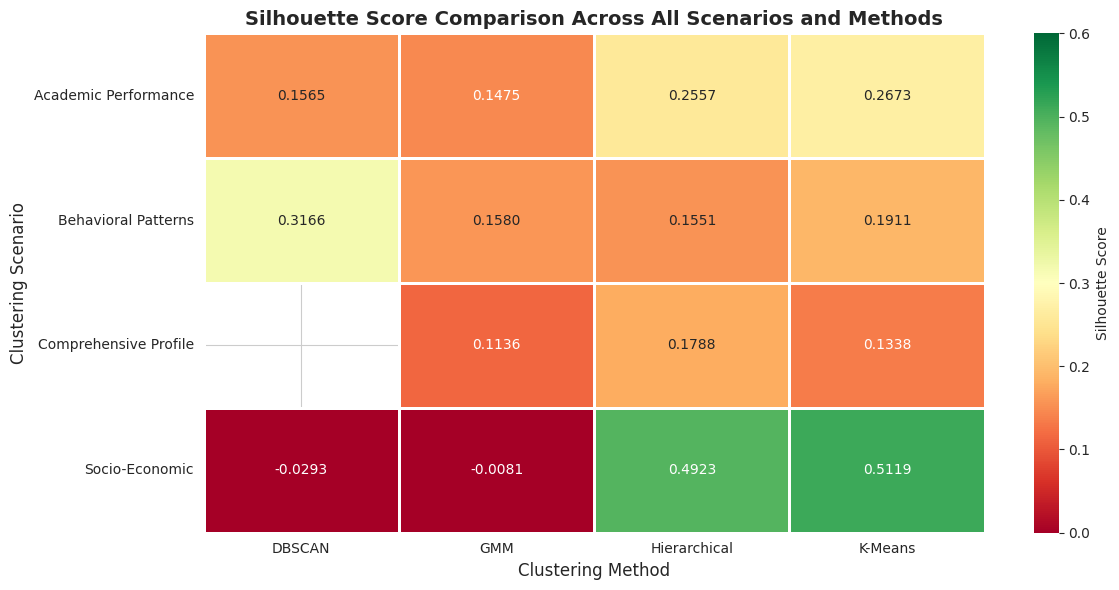

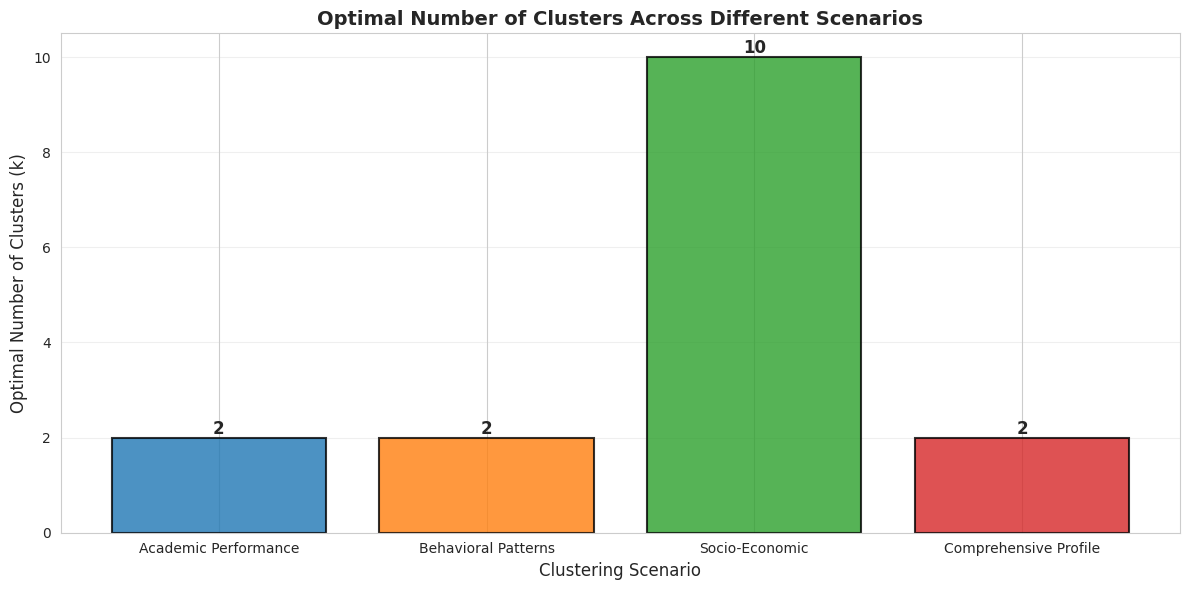


COMPREHENSIVE SUMMARY - ALL SCENARIOS AND METHODS

Best Method for Each Scenario (based on Silhouette Score):

Academic Performance:
  Best Method: K-Means
  Silhouette Score: 0.2673
  Number of Clusters: 2
  Davies-Bouldin: 1.7736 (lower is better)

Behavioral Patterns:
  Best Method: DBSCAN
  Silhouette Score: 0.3166
  Number of Clusters: 2
  Davies-Bouldin: 0.7460 (lower is better)

Socio-Economic:
  Best Method: K-Means
  Silhouette Score: 0.5119
  Number of Clusters: 10
  Davies-Bouldin: 0.7583 (lower is better)

Comprehensive Profile:
  Best Method: Hierarchical
  Silhouette Score: 0.1788
  Number of Clusters: 2
  Davies-Bouldin: 2.5645 (lower is better)



In [51]:
# Create comprehensive summary comparison across all scenarios
summary_data = []

scenarios_summary = [
    ("Academic Performance", optimal_k_academic, X_academic,
     [labels_kmeans_academic, labels_hierarchical_academic, labels_dbscan_academic, labels_gmm_academic]),
    ("Behavioral Patterns", optimal_k_behavioral, X_behavioral,
     [labels_kmeans_behavioral, labels_hierarchical_behavioral, labels_dbscan_behavioral, labels_gmm_behavioral]),
    ("Socio-Economic", optimal_k_socioeconomic, X_socioeconomic,
     [labels_kmeans_socioeconomic, labels_hierarchical_socioeconomic, labels_dbscan_socioeconomic, labels_gmm_socioeconomic]),
    ("Comprehensive Profile", optimal_k_comprehensive, X_comprehensive,
     [labels_kmeans_comprehensive, labels_hierarchical_comprehensive, labels_dbscan_comprehensive, labels_gmm_comprehensive])
]

methods = ["K-Means", "Hierarchical", "DBSCAN", "GMM"]

for scenario_name, optimal_k, X_data, all_labels in scenarios_summary:
    for method_name, labels in zip(methods, all_labels):
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters >= 2:
            mask = labels != -1
            if sum(mask) > 0:
                sil, db, ch = evaluate_clustering(X_data[mask], labels[mask])
            else:
                sil, db, ch = None, None, None
        else:
            sil, db, ch = None, None, None

        summary_data.append({
            'Scenario': scenario_name,
            'Method': method_name,
            'Optimal_K': optimal_k,
            'Clusters': n_clusters,
            'Silhouette': sil,
            'Davies_Bouldin': db,
            'Calinski_Harabasz': ch
        })

summary_df = pd.DataFrame(summary_data)

# Create heatmap for Silhouette scores
pivot_silhouette = summary_df.pivot(index='Scenario', columns='Method', values='Silhouette')

fig_heatmap = plt.figure(figsize=(12, 6))
sns.heatmap(pivot_silhouette, annot=True, fmt='.4f', cmap='RdYlGn',
            center=0.3, vmin=0, vmax=0.6, linewidths=1, cbar_kws={'label': 'Silhouette Score'})
plt.title('Silhouette Score Comparison Across All Scenarios and Methods',
          fontsize=14, fontweight='bold')
plt.xlabel('Clustering Method', fontsize=12)
plt.ylabel('Clustering Scenario', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/summary_silhouette_heatmap.png')
plt.show()
plt.close(fig_heatmap)

# Bar chart comparing optimal k across scenarios
fig_bar, ax = plt.subplots(1, 1, figsize=(12, 6))
scenarios_names = [s[0] for s in scenarios_summary]
optimal_ks = [s[1] for s in scenarios_summary]

bars = ax.bar(scenarios_names, optimal_ks, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
              edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_ylabel('Optimal Number of Clusters (k)', fontsize=12)
ax.set_xlabel('Clustering Scenario', fontsize=12)
ax.set_title('Optimal Number of Clusters Across Different Scenarios', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/summary_optimal_k_bar.png')
plt.show()
plt.close(fig_bar)

print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY - ALL SCENARIOS AND METHODS")
print("="*80)
print("\nBest Method for Each Scenario (based on Silhouette Score):")
for scenario in scenarios_names:
    scenario_data = summary_df[summary_df['Scenario'] == scenario]
    best_row = scenario_data.loc[scenario_data['Silhouette'].idxmax()]
    print(f"\n{scenario}:")
    print(f"  Best Method: {best_row['Method']}")
    print(f"  Silhouette Score: {best_row['Silhouette']:.4f}")
    print(f"  Number of Clusters: {int(best_row['Clusters'])}")
    print(f"  Davies-Bouldin: {best_row['Davies_Bouldin']:.4f} (lower is better)")

print("\n" + "="*80)

## Detailed Interpretations & Educational Insights

### 1. Academic Performance Clustering Insights

**Key Findings:**
- **High Achievers**: Students with consistent high grades (G1, G2, G3 > 15), moderate study time, minimal failures
  - *Action*: Offer advanced placement courses, research opportunities
  
- **Struggling Students**: Low grades, high failure rates, despite support systems
  - *Action*: Intensive tutoring, study skills workshops, mental health support
  
- **Improving Students**: Show grade progression from G1 to G3
  - *Action*: Positive reinforcement, maintain current support structures
  
- **Underperformers with Potential**: Low study time but moderate grades
  - *Action*: Motivation programs, time management training

**Why Multiple Methods?**
- K-Means: Quick identification of average performance levels
- Hierarchical: Shows progression pathways between performance tiers
- DBSCAN: Identifies exceptional outliers (genius or extremely struggling)
- GMM: Captures uncertainty - students on the boundary between groups

---

### 2. Behavioral Pattern Clustering Insights

**Key Findings:**
- **Balanced Students**: Moderate social life, minimal alcohol, good health
  - *Action*: Use as peer mentors
  
- **Social Butterflies**: High goout scores, active in extracurriculars
  - *Action*: Channel energy into leadership roles
  
- **At-Risk Group**: High alcohol consumption (Dalc, Walc), many absences
  - *Action*: Wellness programs, counseling services, early intervention
  
- **Isolated Students**: Low social activity, no romantic relationships
  - *Action*: Social integration programs, peer buddy systems

**Educational Impact:**
- Correlation between behavioral clusters and academic outcomes
- Early warning system for at-risk behaviors
- Personalized wellness interventions

---

### 3. Socio-Economic Background Clustering Insights

**Key Findings:**
- **Privileged Background**: High parent education (Medu, Fedu = 4), professional jobs, internet access
  - *Action*: Leverage family resources, expect higher performance
  
- **Working Class**: Lower parent education, service/manual labor jobs
  - *Action*: Additional academic support, career guidance
  
- **Single Parent Families**: Pstatus = 'A' (apart)
  - *Action*: Flexible scheduling, single-parent support groups
  
- **Rural Students**: Address = 'R', longer travel times
  - *Action*: Transportation assistance, boarding options

**Equity Considerations:**
- Identify gaps in resource access
- Target scholarships and financial aid
- Design inclusive policies that level the playing field
- Family engagement strategies tailored to each socio-economic group

---

### 4. Comprehensive Profile Clustering Insights

**Holistic Student Archetypes:**

- **Elite Performers**: High grades + privileged background + balanced behavior
  - *Action*: Honors programs, university preparation
  
- **Resilient Achievers**: Good grades despite challenging backgrounds
  - *Action*: Mentorship, scholarship opportunities
  
- **Struggling with Support Needs**: Low grades + at-risk behaviors + low socio-economic status
  - *Action*: Comprehensive intervention - academic, social, financial
  
- **Underachievers**: Good background but poor academic/behavioral outcomes
  - *Action*: Motivation counseling, identify underlying issues

**Why Comprehensive Clustering Matters:**
- Reveals complex interactions between factors
- Single-dimension approaches miss important patterns
- Enables truly personalized education
- Holistic student support strategies

---

### Method Comparison Summary

**When to Use Each Method:**

1. **K-Means**
   - ✅ Fast, interpretable, works well with clear separations
   - ✅ Best for: Initial exploratory analysis, large datasets
   - ❌ Assumes spherical clusters, sensitive to outliers

2. **Hierarchical Clustering**
   - ✅ Shows relationships between clusters, no need to specify k beforehand
   - ✅ Best for: Understanding progression levels, smaller datasets
   - ❌ Computationally expensive, sensitive to noise

3. **DBSCAN**
   - ✅ Finds outliers, handles arbitrary shapes, robust to noise
   - ✅ Best for: Identifying exceptional students, anomaly detection
   - ❌ Struggles with varying density, parameter tuning challenging

4. **Gaussian Mixture Models**
   - ✅ Probabilistic assignments, handles overlapping clusters
   - ✅ Best for: Understanding cluster boundaries, soft assignments
   - ❌ May overfit, requires more computation

---

### Overall Conclusions

**For AI-Based Educational Data Mining:**

1. **Multiple perspectives are essential** - Academic, behavioral, and socio-economic factors all matter
2. **No single clustering method is best** - Each reveals different insights
3. **Actionable insights require interpretation** - Raw clusters mean nothing without domain knowledge
4. **Personalization is key** - One-size-fits-all approaches fail
5. **Early intervention works** - Predictive patterns enable proactive support
6. **Equity matters** - Socio-economic clustering reveals systemic issues
7. **Holistic approaches win** - Comprehensive profiling captures complexity

**Recommendations for Educational Institutions:**
- Implement multi-method clustering pipelines
- Regular re-clustering as students evolve
- Combine clustering with supervised learning for outcome prediction
- Use clusters to design targeted intervention programs
- Respect privacy and ethical considerations
- Involve educators in interpretation - AI insights need human wisdom

### Behavioral Clusters vs Academic Performance Analysis

**Research Question:** Do students with similar behavioral patterns show different academic outcomes?

This analysis examines how lifestyle and behavioral choices correlate with academic achievement.

BEHAVIORAL PATTERNS vs ACADEMIC PERFORMANCE

--- Average Academic Performance by Behavioral Cluster ---
                       G1    G2     G3  studytime  failures  absences
Behavioral_Cluster                                                   
0                   10.45  7.94  10.51       1.72      0.40      6.53
1                   11.52  6.61  11.68       2.07      0.21      3.60

--- Behavioral Cluster Profiles ---

🎯 Behavioral Cluster 0 (299 students, 28.6%):
   Behavioral Characteristics:
     - Going Out: 4.05/5
     - Alcohol (Weekday/Weekend): 2.43/3.84
     - Free Time: 3.63/5
     - Health: 3.77/5
     - Absences: 6.5
   Academic Performance:
     - Average Final Grade (G3): 10.51
     - Study Time: 1.72/4
     - Failures: 0.40
     - Pass Rate (G3≥10): 71.2%

🎯 Behavioral Cluster 1 (745 students, 71.4%):
   Behavioral Characteristics:
     - Going Out: 2.80/5
     - Alcohol (Weekday/Weekend): 1.12/1.66
     - Free Time: 3.03/5
     - Health: 3.45/5
     - Absences: 3.6
   Ac

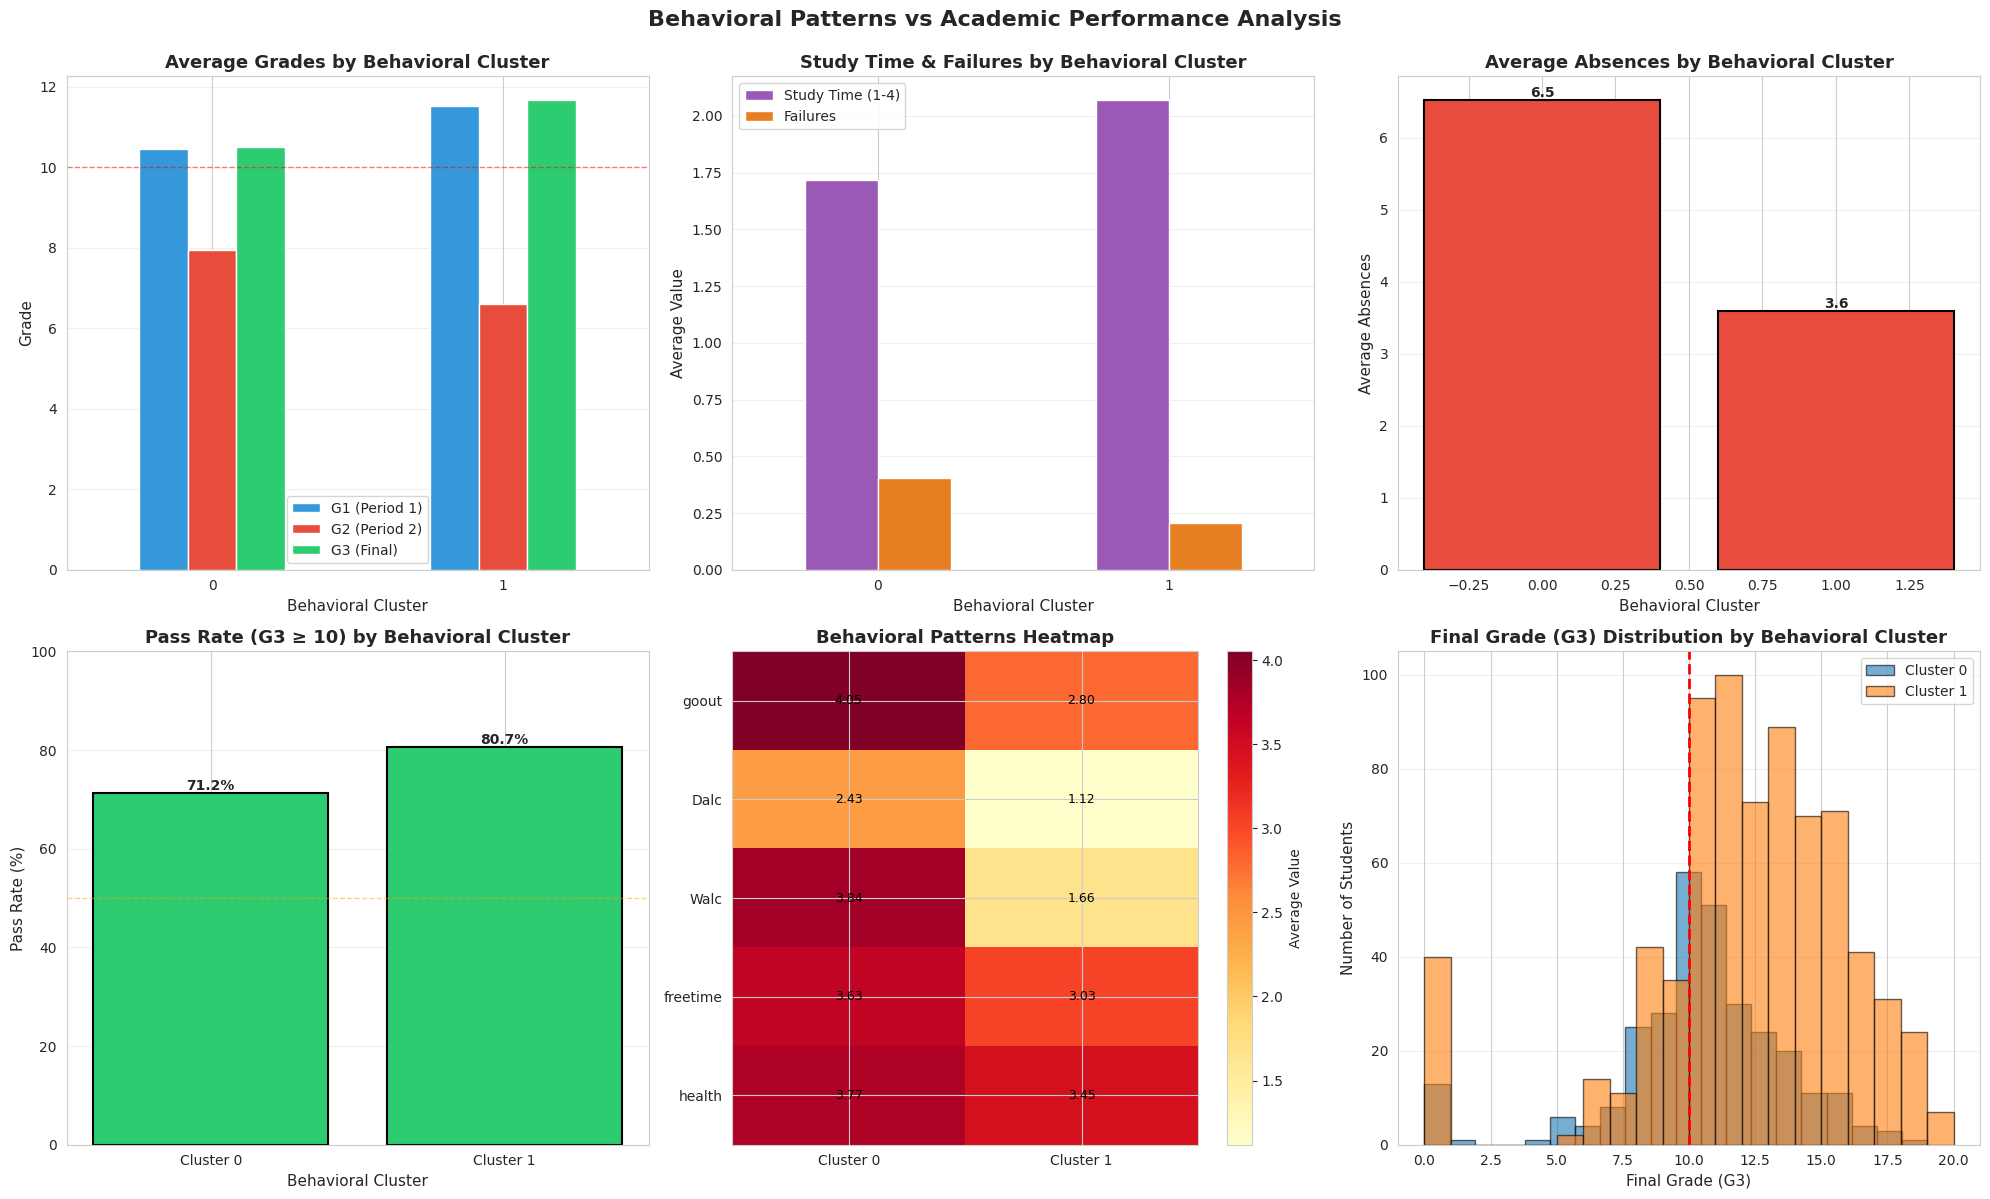

In [52]:
# Compare Behavioral Clusters with Academic Performance
print("="*80)
print("BEHAVIORAL PATTERNS vs ACADEMIC PERFORMANCE")
print("="*80)

# Add behavioral cluster labels to dataframe
df_behavior_analysis = df_processed.copy() # Changed from df.copy() to df_processed.copy()
df_behavior_analysis['Behavioral_Cluster'] = labels_kmeans_behavioral

# Calculate average academic performance by behavioral cluster
academic_cols = ['G1', 'G2', 'G3', 'studytime', 'failures', 'absences']
behavioral_academic_summary = df_behavior_analysis.groupby('Behavioral_Cluster')[academic_cols].mean()

print("\n--- Average Academic Performance by Behavioral Cluster ---")
print(behavioral_academic_summary.round(2))

# Statistical analysis
print("\n--- Behavioral Cluster Profiles ---")
for cluster_id in sorted(df_behavior_analysis['Behavioral_Cluster'].unique()):
    cluster_data = df_behavior_analysis[df_behavior_analysis['Behavioral_Cluster'] == cluster_id]
    n_students = len(cluster_data)

    print(f"\n🎯 Behavioral Cluster {cluster_id} ({n_students} students, {n_students/len(df)*100:.1f}%):")
    print(f"   Behavioral Characteristics:")
    print(f"     - Going Out: {cluster_data['goout'].mean():.2f}/5")
    print(f"     - Alcohol (Weekday/Weekend): {cluster_data['Dalc'].mean():.2f}/{cluster_data['Walc'].mean():.2f}")
    print(f"     - Free Time: {cluster_data['freetime'].mean():.2f}/5")
    print(f"     - Health: {cluster_data['health'].mean():.2f}/5")
    print(f"     - Absences: {cluster_data['absences'].mean():.1f}")
    print(f"   Academic Performance:")
    print(f"     - Average Final Grade (G3): {cluster_data['G3'].mean():.2f}")
    print(f"     - Study Time: {cluster_data['studytime'].mean():.2f}/4")
    print(f"     - Failures: {cluster_data['failures'].mean():.2f}")
    print(f"     - Pass Rate (G3\u226510): {(cluster_data['G3'] >= 10).sum()/len(cluster_data)*100:.1f}%")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Average Grades by Behavioral Cluster
ax = axes[0, 0]
behavioral_academic_summary[['G1', 'G2', 'G3']].plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_title('Average Grades by Behavioral Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Behavioral Cluster', fontsize=11)
ax.set_ylabel('Grade', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['G1 (Period 1)', 'G2 (Period 2)', 'G3 (Final)'])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=10, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Pass Threshold')

# 2. Study Time vs Behavioral Cluster
ax = axes[0, 1]
study_fail_data = behavioral_academic_summary[['studytime', 'failures']]
study_fail_data.plot(kind='bar', ax=ax, color=['#9b59b6', '#e67e22'])
ax.set_title('Study Time & Failures by Behavioral Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Behavioral Cluster', fontsize=11)
ax.set_ylabel('Average Value', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Study Time (1-4)', 'Failures'])
ax.grid(axis='y', alpha=0.3)

# 3. Absences vs Behavioral Cluster
ax = axes[0, 2]
abs_data = behavioral_academic_summary['absences']
bars = ax.bar(abs_data.index, abs_data.values, color='#e74c3c', edgecolor='black', linewidth=1.5)
ax.set_title('Average Absences by Behavioral Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Behavioral Cluster', fontsize=11)
ax.set_ylabel('Average Absences', fontsize=11)
ax.grid(axis='y', alpha=0.3)
# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

# 4. Pass Rate by Behavioral Cluster
ax = axes[1, 0]
pass_rates = []
cluster_labels = []
for cluster_id in sorted(df_behavior_analysis['Behavioral_Cluster'].unique()):
    cluster_data = df_behavior_analysis[df_behavior_analysis['Behavioral_Cluster'] == cluster_id]
    pass_rate = (cluster_data['G3'] >= 10).sum() / len(cluster_data) * 100
    pass_rates.append(pass_rate)
    cluster_labels.append(f'Cluster {cluster_id}')

bars = ax.bar(cluster_labels, pass_rates, color='#2ecc71', edgecolor='black', linewidth=1.5)
ax.set_title('Pass Rate (G3 \u2265 10) by Behavioral Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Behavioral Cluster', fontsize=11)
ax.set_ylabel('Pass Rate (%)', fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=50, color='orange', linestyle='--', linewidth=1, alpha=0.5)
# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 5. Behavioral Features Heatmap by Cluster
ax = axes[1, 1]
behavioral_summary = df_behavior_analysis.groupby('Behavioral_Cluster')[['goout', 'Dalc', 'Walc', 'freetime', 'health']].mean()
im = ax.imshow(behavioral_summary.T, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(len(behavioral_summary.columns)))
ax.set_yticklabels(behavioral_summary.columns)
ax.set_xticks(range(len(behavioral_summary)))
ax.set_xticklabels([f'Cluster {i}' for i in behavioral_summary.index])
ax.set_title('Behavioral Patterns Heatmap', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Average Value')
# Add values to heatmap
for i in range(len(behavioral_summary.columns)):
    for j in range(len(behavioral_summary)):
        text = ax.text(j, i, f'{behavioral_summary.iloc[j, i]:.2f}',
                      ha="center", va="center", color="black", fontsize=9)

# 6. Grade Distribution by Behavioral Cluster
ax = axes[1, 2]
for cluster_id in sorted(df_behavior_analysis['Behavioral_Cluster'].unique()):
    cluster_data = df_behavior_analysis[df_behavior_analysis['Behavioral_Cluster'] == cluster_id]
    ax.hist(cluster_data['G3'], bins=20, alpha=0.6, label=f'Cluster {cluster_id}', edgecolor='black')
ax.set_title('Final Grade (G3) Distribution by Behavioral Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Final Grade (G3)', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Pass Threshold')

plt.suptitle('Behavioral Patterns vs Academic Performance Analysis',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/behavioral_academic_analysis.png')
plt.show()
plt.close(fig)

print("\n" + "="*80)

---
## SOCIO-ECONOMIC PATTERNS vs ACADEMIC PERFORMANCE ANALYSIS
---

### Investigating the Impact of Socio-Economic Background on Student Success

This analysis explores whether socio-economic background clusters show different academic outcomes, addressing critical equity questions in education.

In [33]:
# Create comprehensive analysis dataset for socio-economic patterns
df_socioeconomic_analysis = df_processed.copy()
df_socioeconomic_analysis['SocioEconomic_Cluster'] = labels_kmeans_socioeconomic

print("="*80)
print("SOCIO-ECONOMIC BACKGROUND vs ACADEMIC PERFORMANCE ANALYSIS")
print("="*80)

# 1. Academic Performance by Socio-Economic Cluster
print("\n📊 ACADEMIC PERFORMANCE BY SOCIO-ECONOMIC CLUSTER")
print("-" * 80)

academic_by_socioeconomic = df_socioeconomic_analysis.groupby('SocioEconomic_Cluster').agg({
    'G1': 'mean',
    'G2': 'mean',
    'G3': 'mean',
    'failures': 'mean',
    'absences': 'mean',
    'studytime': 'mean'
}).round(2)

print("\nAcademic Metrics by Socio-Economic Cluster:")
print(academic_by_socioeconomic)

# Calculate pass rates
print("\n📈 PASS RATES (G3 >= 10) BY SOCIO-ECONOMIC CLUSTER:")
print("-" * 80)
for cluster_id in sorted(df_socioeconomic_analysis['SocioEconomic_Cluster'].unique()):
    cluster_data = df_socioeconomic_analysis[df_socioeconomic_analysis['SocioEconomic_Cluster'] == cluster_id]
    pass_rate = (cluster_data['G3'] >= 10).sum() / len(cluster_data) * 100
    avg_grade = cluster_data['G3'].mean()
    print(f"Cluster {cluster_id}: {pass_rate:.1f}% pass rate | Avg Grade: {avg_grade:.2f} | n={len(cluster_data)}")

# Helper function to get the encoded value for a string category
def get_encoded_value(col_name, category_string):
    return list(label_encoders[col_name].classes_).index(category_string)

# 2. Socio-Economic Characteristics by Cluster
print("\n🏠 SOCIO-ECONOMIC CHARACTERISTICS BY CLUSTER:")
print("-" * 80)

socioeconomic_summary = df_socioeconomic_analysis.groupby('SocioEconomic_Cluster').agg({
    'Medu': 'mean',
    'Fedu': 'mean',
    'traveltime': 'mean',
    'internet': lambda x: (x == get_encoded_value('internet', 'yes')).sum() / len(x) * 100,
    'address': lambda x: (x == get_encoded_value('address', 'U')).sum() / len(x) * 100,
    'famsize': lambda x: (x == get_encoded_value('famsize', 'GT3')).sum() / len(x) * 100
}).round(2)

socioeconomic_summary.columns = ['Mother Edu', 'Father Edu', 'Travel Time', 'Internet %', 'Urban %', 'Large Family %']
print(socioeconomic_summary)

# 3. Educational Support & Resources by Cluster
print("\n📚 EDUCATIONAL SUPPORT & RESOURCES BY CLUSTER:")
print("-" * 80)

support_summary = df_socioeconomic_analysis.groupby('SocioEconomic_Cluster').agg({
    'schoolsup': lambda x: (x == get_encoded_value('schoolsup', 'yes')).sum() / len(x) * 100,
    'famsup': lambda x: (x == get_encoded_value('famsup', 'yes')).sum() / len(x) * 100,
    'paid': lambda x: (x == get_encoded_value('paid', 'yes')).sum() / len(x) * 100,
    'higher': lambda x: (x == get_encoded_value('higher', 'yes')).sum() / len(x) * 100
}).round(1)

support_summary.columns = ['School Support %', 'Family Support %', 'Paid Classes %', 'Higher Edu Goal %']
print(support_summary)

print("\n" + "="*80)

SOCIO-ECONOMIC BACKGROUND vs ACADEMIC PERFORMANCE ANALYSIS

📊 ACADEMIC PERFORMANCE BY SOCIO-ECONOMIC CLUSTER
--------------------------------------------------------------------------------

Academic Metrics by Socio-Economic Cluster:
                          G1    G2     G3  failures  absences  studytime
SocioEconomic_Cluster                                                   
0                      11.21  6.93  11.67      0.27      6.39       1.96
1                      11.83  6.75  12.02      0.17      4.39       2.06
2                      10.44  7.30  10.40      0.38      3.91       1.86

📈 PASS RATES (G3 >= 10) BY SOCIO-ECONOMIC CLUSTER:
--------------------------------------------------------------------------------
Cluster 0: 81.0% pass rate | Avg Grade: 11.67 | n=121
Cluster 1: 82.1% pass rate | Avg Grade: 12.02 | n=513
Cluster 2: 72.0% pass rate | Avg Grade: 10.40 | n=410

🏠 SOCIO-ECONOMIC CHARACTERISTICS BY CLUSTER:
-----------------------------------------------------------

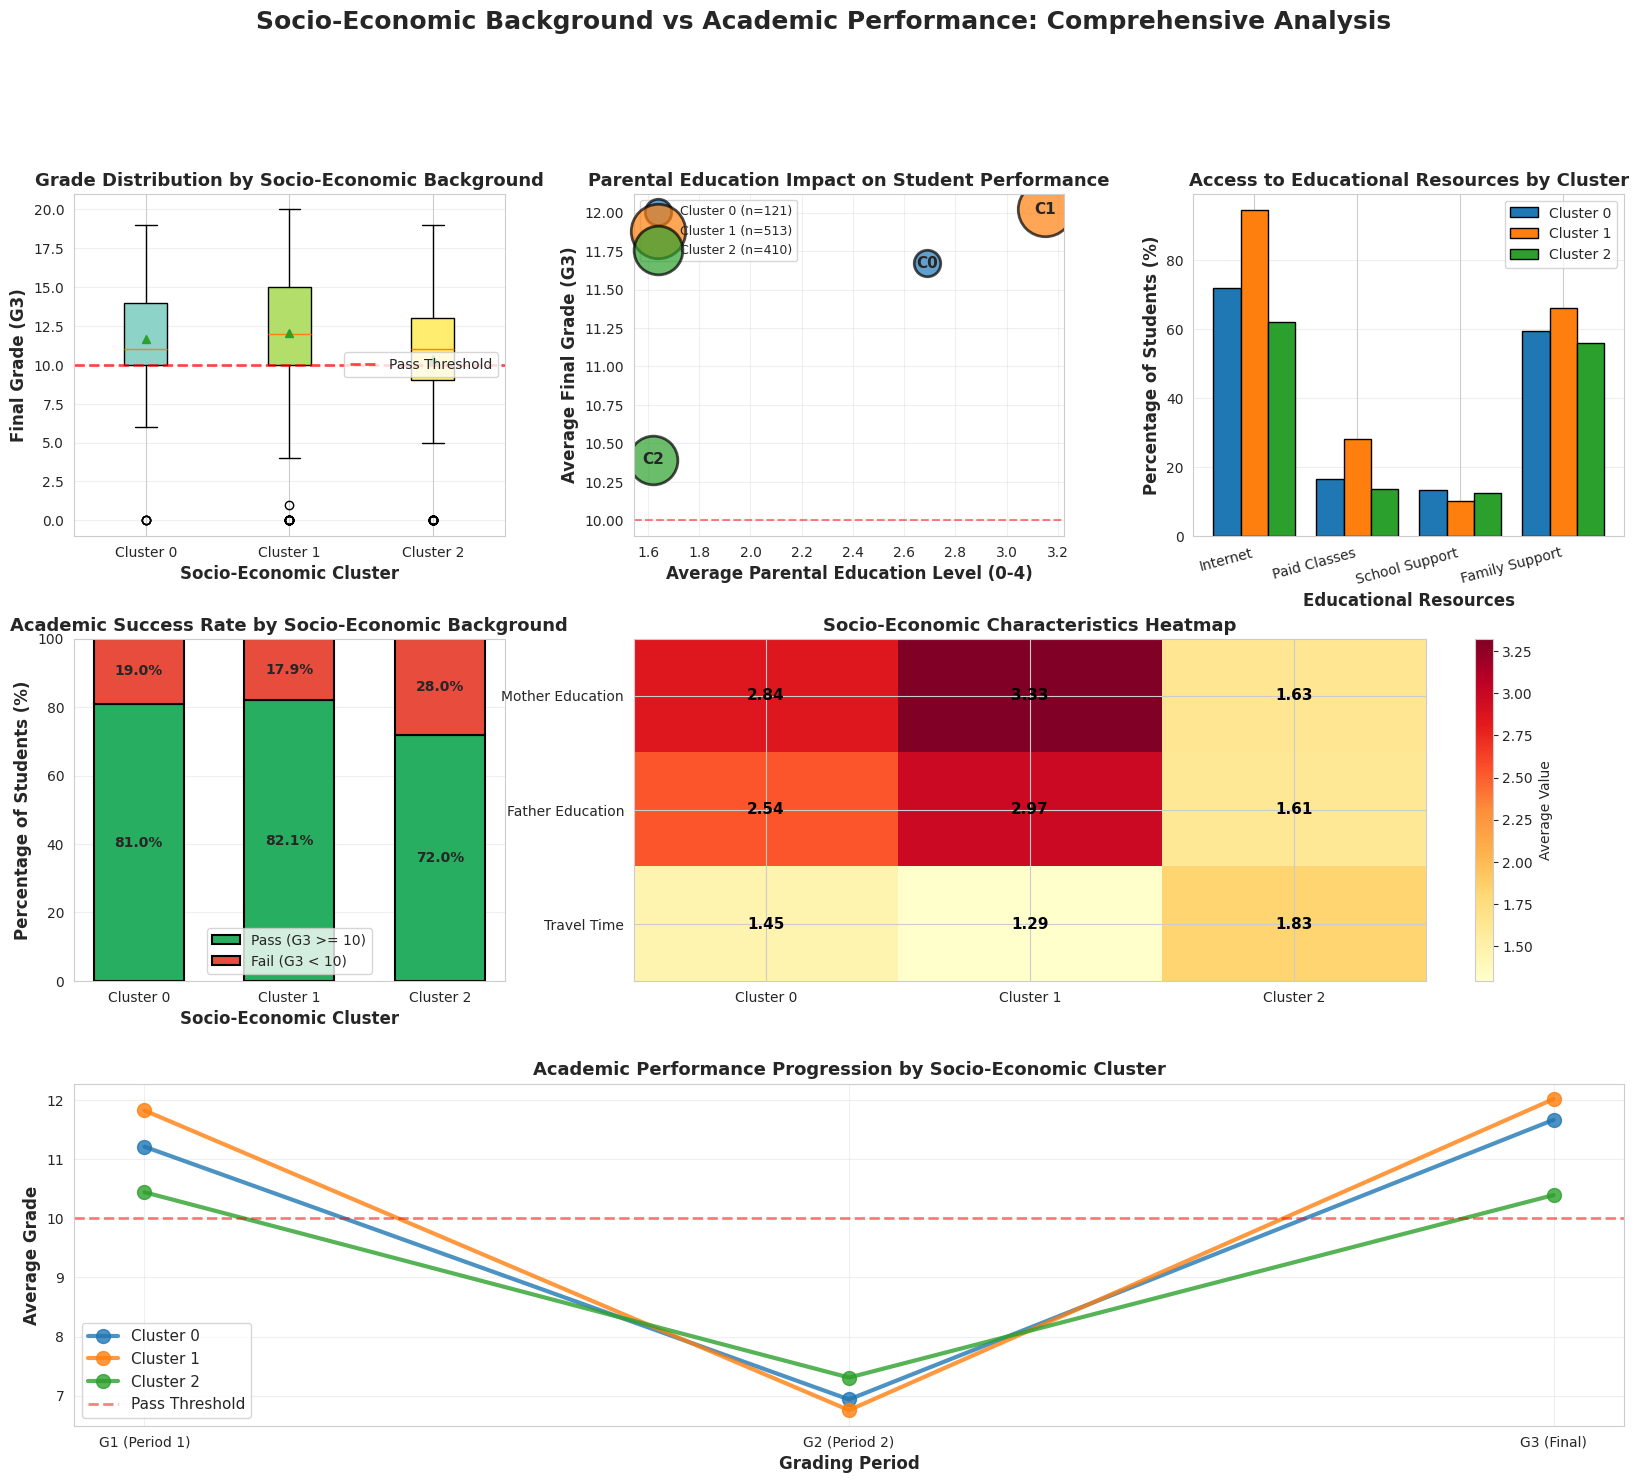

In [53]:
# Create comprehensive visualization dashboard for socio-economic analysis
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Academic Performance Box Plot by Cluster
ax1 = fig.add_subplot(gs[0, 0])
cluster_order = sorted(df_socioeconomic_analysis['SocioEconomic_Cluster'].unique())
grade_data = [df_socioeconomic_analysis[df_socioeconomic_analysis['SocioEconomic_Cluster'] == c]['G3'].values
              for c in cluster_order]

bp = ax1.boxplot(grade_data, labels=[f'Cluster {c}' for c in cluster_order],
                 patch_artist=True, showmeans=True)

# Color the boxes
colors = plt.cm.Set3(np.linspace(0, 1, len(cluster_order)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax1.set_ylabel('Final Grade (G3)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Socio-Economic Cluster', fontsize=12, fontweight='bold')
ax1.set_title('Grade Distribution by Socio-Economic Background', fontsize=13, fontweight='bold')
ax1.axhline(y=10, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Pass Threshold')
ax1.grid(axis='y', alpha=0.3)
ax1.legend()

# 2. Parental Education vs Academic Performance
ax2 = fig.add_subplot(gs[0, 1])
for cluster_id in cluster_order:
    cluster_data = df_socioeconomic_analysis[df_socioeconomic_analysis['SocioEconomic_Cluster'] == cluster_id]
    avg_parent_edu = (cluster_data['Medu'].mean() + cluster_data['Fedu'].mean()) / 2
    avg_grade = cluster_data['G3'].mean()

    ax2.scatter(avg_parent_edu, avg_grade, s=len(cluster_data)*3, alpha=0.7,
               label=f'Cluster {cluster_id} (n={len(cluster_data)})', edgecolors='black', linewidth=2)
    ax2.text(avg_parent_edu, avg_grade, f'C{cluster_id}', fontsize=11, fontweight='bold',
            ha='center', va='center')

ax2.set_xlabel('Average Parental Education Level (0-4)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Final Grade (G3)', fontsize=12, fontweight='bold')
ax2.set_title('Parental Education Impact on Student Performance', fontsize=13, fontweight='bold')
ax2.axhline(y=10, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

# 3. Resource Access Comparison
ax3 = fig.add_subplot(gs[0, 2])
resources = ['Internet', 'Paid Classes', 'School Support', 'Family Support']
cluster_resources = []

for cluster_id in cluster_order:
    cluster_data = df_socioeconomic_analysis[df_socioeconomic_analysis['SocioEconomic_Cluster'] == cluster_id]
    cluster_resources.append([
        (cluster_data['internet'] == get_encoded_value('internet', 'yes')).sum() / len(cluster_data) * 100,
        (cluster_data['paid'] == get_encoded_value('paid', 'yes')).sum() / len(cluster_data) * 100,
        (cluster_data['schoolsup'] == get_encoded_value('schoolsup', 'yes')).sum() / len(cluster_data) * 100,
        (cluster_data['famsup'] == get_encoded_value('famsup', 'yes')).sum() / len(cluster_data) * 100
    ])

x = np.arange(len(resources))
width = 0.8 / len(cluster_order)

for i, cluster_id in enumerate(cluster_order):
    ax3.bar(x + i*width, cluster_resources[i], width,
           label=f'Cluster {cluster_id}', edgecolor='black', linewidth=1)

ax3.set_ylabel('Percentage of Students (%)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Educational Resources', fontsize=12, fontweight='bold')
ax3.set_title('Access to Educational Resources by Cluster', fontsize=13, fontweight='bold')
ax3.set_xticks(x + width * (len(cluster_order)-1) / 2)
ax3.set_xticklabels(resources, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Success Rate Comparison
ax4 = fig.add_subplot(gs[1, 0])
success_rates = []
failure_rates = []
labels_list = []

for cluster_id in cluster_order:
    cluster_data = df_socioeconomic_analysis[df_socioeconomic_analysis['SocioEconomic_Cluster'] == cluster_id]
    pass_rate = (cluster_data['G3'] >= 10).sum() / len(cluster_data) * 100
    fail_rate = 100 - pass_rate
    success_rates.append(pass_rate)
    failure_rates.append(fail_rate)
    labels_list.append(f'Cluster {cluster_id}')

x = np.arange(len(labels_list))
width = 0.6

p1 = ax4.bar(x, success_rates, width, label='Pass (G3 >= 10)', color='#27ae60', edgecolor='black', linewidth=1.5)
p2 = ax4.bar(x, failure_rates, width, bottom=success_rates, label='Fail (G3 < 10)',
            color='#e74c3c', edgecolor='black', linewidth=1.5)

ax4.set_ylabel('Percentage of Students (%)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Socio-Economic Cluster', fontsize=12, fontweight='bold')
ax4.set_title('Academic Success Rate by Socio-Economic Background', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(labels_list)
ax4.legend()
ax4.set_ylim(0, 100)
ax4.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (p, f) in enumerate(zip(success_rates, failure_rates)):
    ax4.text(i, p/2, f'{p:.1f}%', ha='center', va='center', fontweight='bold', fontsize=10)
    ax4.text(i, p + f/2, f'{f:.1f}%', ha='center', va='center', fontweight='bold', fontsize=10)

# 5. Socio-Economic Characteristics Heatmap
ax5 = fig.add_subplot(gs[1, 1:])
socioeconomic_features = ['Medu', 'Fedu', 'traveltime']
se_summary = df_socioeconomic_analysis.groupby('SocioEconomic_Cluster')[socioeconomic_features].mean()

im = ax5.imshow(se_summary.T, cmap='YlOrRd', aspect='auto')
ax5.set_yticks(range(len(socioeconomic_features)))
ax5.set_yticklabels(['Mother Education', 'Father Education', 'Travel Time'])
ax5.set_xticks(range(len(se_summary)))
ax5.set_xticklabels([f'Cluster {i}' for i in se_summary.index])
ax5.set_title('Socio-Economic Characteristics Heatmap', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax5, label='Average Value')

# Add values to heatmap
for i in range(len(socioeconomic_features)):
    for j in range(len(se_summary)):
        text = ax5.text(j, i, f'{se_summary.iloc[j, i]:.2f}',
                      ha="center", va="center", color="black", fontsize=11, fontweight='bold')

# 6. Grade Progression Across Clusters
ax6 = fig.add_subplot(gs[2, :])
for cluster_id in cluster_order:
    cluster_data = df_socioeconomic_analysis[df_socioeconomic_analysis['SocioEconomic_Cluster'] == cluster_id]
    grades = [cluster_data['G1'].mean(), cluster_data['G2'].mean(), cluster_data['G3'].mean()]
    ax6.plot(['G1 (Period 1)', 'G2 (Period 2)', 'G3 (Final)'], grades,
            marker='o', linewidth=3, markersize=10, label=f'Cluster {cluster_id}', alpha=0.8)

ax6.set_ylabel('Average Grade', fontsize=12, fontweight='bold')
ax6.set_xlabel('Grading Period', fontsize=12, fontweight='bold')
ax6.set_title('Academic Performance Progression by Socio-Economic Cluster', fontsize=13, fontweight='bold')
ax6.axhline(y=10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Pass Threshold')
ax6.legend(fontsize=11, loc='best')
ax6.grid(True, alpha=0.3)

plt.suptitle('Socio-Economic Background vs Academic Performance: Comprehensive Analysis',
             fontsize=18, fontweight='bold', y=0.995)
plt.savefig(f'{SAVE_DIR}/socioeconomic_academic_dashboard.png')
plt.show()
plt.close(fig)

print("\n" + "="*80)

---
# TIME SERIES ANALYSIS: GRADE PROGRESSION ACROSS THREE TERMS
---

## Understanding Student Performance Trajectories

This section analyzes how student grades evolve across the three grading periods (G1, G2, G3), identifying:
- **Improvement patterns**: Students who get better over time
- **Decline patterns**: Students whose performance deteriorates
- **Stability patterns**: Consistent performers
- **At-risk students**: Early indicators of academic struggle
- **Success predictors**: Which early grades best predict final outcomes

In [36]:
# Prepare data for time series analysis
print("="*80)
print("TIME SERIES ANALYSIS: GRADE PROGRESSION (G1 → G2 → G3)")
print("="*80)

# Calculate grade changes
df_timeseries = df_processed.copy() # Changed from df.copy() to df_processed.copy()
df_timeseries['G1_to_G2_change'] = df_timeseries['G2'] - df_timeseries['G1']
df_timeseries['G2_to_G3_change'] = df_timeseries['G3'] - df_timeseries['G2']
df_timeseries['G1_to_G3_change'] = df_timeseries['G3'] - df_timeseries['G1']

# Calculate percentage changes
# Add a small epsilon to G1 and G2 to avoid division by zero for percentage changes
df_timeseries['G1_to_G2_pct'] = ((df_timeseries['G2'] - df_timeseries['G1']) / (df_timeseries['G1'] + 0.1)) * 100
df_timeseries['G2_to_G3_pct'] = ((df_timeseries['G3'] - df_timeseries['G2']) / (df_timeseries['G2'] + 0.1)) * 100

# Classify performance trajectories
def classify_trajectory(row):
    g1, g2, g3 = row['G1'], row['G2'], row['G3']

    if g3 > g2 > g1:
        return 'Consistent Improver'
    elif g3 < g2 < g1:
        return 'Consistent Decliner'
    elif g3 > g1 and g2 >= g1:
        return 'Overall Improver'
    elif g3 < g1 and g2 <= g1:
        return 'Overall Decliner'
    elif abs(g3 - g1) <= 1:
        return 'Stable Performer'
    elif g2 > g1 and g3 < g2:
        return 'Mid-term Peak'
    elif g2 < g1 and g3 > g2:
        return 'Mid-term Dip'
    else:
        return 'Erratic'

df_timeseries['Trajectory'] = df_timeseries.apply(classify_trajectory, axis=1)

# Overall statistics
print("\n📊 OVERALL GRADE PROGRESSION STATISTICS")
print("-" * 80)
print(f"\nAverage Grades:")
print(f"  G1 (Period 1): {df_timeseries['G1'].mean():.2f} ± {df_timeseries['G1'].std():.2f}")
print(f"  G2 (Period 2): {df_timeseries['G2'].mean():.2f} ± {df_timeseries['G2'].std():.2f}")
print(f"  G3 (Final):    {df_timeseries['G3'].mean():.2f} ± {df_timeseries['G3'].std():.2f}")

print(f"\nAverage Changes:")
print(f"  G1 → G2: {df_timeseries['G1_to_G2_change'].mean():+.2f} points ({df_timeseries['G1_to_G2_pct'].mean():+.1f}%)")
print(f"  G2 → G3: {df_timeseries['G2_to_G3_change'].mean():+.2f} points ({df_timeseries['G2_to_G3_pct'].mean():+.1f}%)")
print(f"  G1 → G3: {df_timeseries['G1_to_G3_change'].mean():+.2f} points")

# Performance trajectory distribution
print(f"\n📈 PERFORMANCE TRAJECTORY DISTRIBUTION")
print("-" * 80)
trajectory_counts = df_timeseries['Trajectory'].value_counts()
for trajectory, count in trajectory_counts.items():
    pct = count / len(df_timeseries) * 100
    avg_final = df_timeseries[df_timeseries['Trajectory'] == trajectory]['G3'].mean()
    print(f"  {trajectory:.<25} {count:>4} students ({pct:>5.1f}%) | Avg G3: {avg_final:.2f}")

# Improvement and decline statistics
print(f"\n🎯 IMPROVEMENT & DECLINE ANALYSIS")
print("-" * 80)
improvers = df_timeseries[df_timeseries['G1_to_G3_change'] > 0]
decliners = df_timeseries[df_timeseries['G1_to_G3_change'] < 0]
stable = df_timeseries[df_timeseries['G1_to_G3_change'] == 0]

print(f"\nOverall G1 → G3:")
print(f"  Improved:  {len(improvers)} students ({len(improvers)/len(df_timeseries)*100:.1f}%) | Avg gain: +{improvers['G1_to_G3_change'].mean():.2f}")
print(f"  Declined:  {len(decliners)} students ({len(decliners)/len(df_timeseries)*100:.1f}%) | Avg loss: {decliners['G1_to_G3_change'].mean():.2f}")
print(f"  Stable:    {len(stable)} students ({len(stable)/len(df_timeseries)*100:.1f}%) ")

# Identify at-risk students
at_risk_early = df_timeseries[(df_timeseries['G1'] < 10) | (df_timeseries['G2'] < 10)]
at_risk_final_fail = at_risk_early[at_risk_early['G3'] < 10]

print(f"\n⚠️  AT-RISK STUDENT IDENTIFICATION")
print("-" * 80)
print(f"  Students with G1 or G2 < 10: {len(at_risk_early)} ({len(at_risk_early)/len(df_timeseries)*100:.1f}%)")
print(f"  Of these, failed G3 (< 10):  {len(at_risk_final_fail)} ({len(at_risk_final_fail)/len(at_risk_early)*100:.1f}%)")
print(f"  Recovery rate: {((len(at_risk_early) - len(at_risk_final_fail))/len(at_risk_early)*100):.1f}%")

# Correlations between grades
print(f"\n🔗 CORRELATION ANALYSIS BETWEEN GRADING PERIODS")
print("-" * 80)
from scipy.stats import pearsonr

corr_g1_g2, p_g1_g2 = pearsonr(df_timeseries['G1'], df_timeseries['G2'])
corr_g2_g3, p_g2_g3 = pearsonr(df_timeseries['G2'], df_timeseries['G3'])
corr_g1_g3, p_g1_g3 = pearsonr(df_timeseries['G1'], df_timeseries['G3'])

print(f"\n  G1 ↔ G2: r = {corr_g1_g2:.3f} (p < 0.001) - {'Strong' if abs(corr_g1_g2) > 0.7 else 'Moderate' if abs(corr_g1_g2) > 0.5 else 'Weak'}")
print(f"  G2 ↔ G3: r = {corr_g2_g3:.3f} (p < 0.001) - {'Strong' if abs(corr_g2_g3) > 0.7 else 'Moderate' if abs(corr_g2_g3) > 0.5 else 'Weak'}")
print(f"  G1 ↔ G3: r = {corr_g1_g3:.3f} (p < 0.001) - {'Strong' if abs(corr_g1_g3) > 0.7 else 'Moderate' if abs(corr_g1_g3) > 0.5 else 'Weak'}")

print(f"\n  💡 Interpretation: G2 is the {'best' if corr_g2_g3 > corr_g1_g3 else 'second-best'} predictor of final grades")

print("\n" + "="*80)


TIME SERIES ANALYSIS: GRADE PROGRESSION (G1 → G2 → G3)

📊 OVERALL GRADE PROGRESSION STATISTICS
--------------------------------------------------------------------------------

Average Grades:
  G1 (Period 1): 11.21 ± 2.98
  G2 (Period 2): 6.99 ± 5.79
  G3 (Final):    11.34 ± 3.86

Average Changes:
  G1 → G2: -4.22 points (-24.2%)
  G2 → G3: +4.35 points (+238.6%)
  G1 → G3: +0.13 points

📈 PERFORMANCE TRAJECTORY DISTRIBUTION
--------------------------------------------------------------------------------
  Stable Performer.........  520 students ( 49.8%) | Avg G3: 12.14
  Mid-term Dip.............  183 students ( 17.5%) | Avg G3: 13.64
  Overall Decliner.........  176 students ( 16.9%) | Avg G3: 10.64
  Overall Improver.........  111 students ( 10.6%) | Avg G3: 9.12
  Mid-term Peak............   51 students (  4.9%) | Avg G3: 2.73
  Consistent Decliner......    2 students (  0.2%) | Avg G3: 0.00
  Consistent Improver......    1 students (  0.1%) | Avg G3: 11.00

🎯 IMPROVEMENT & DECLIN

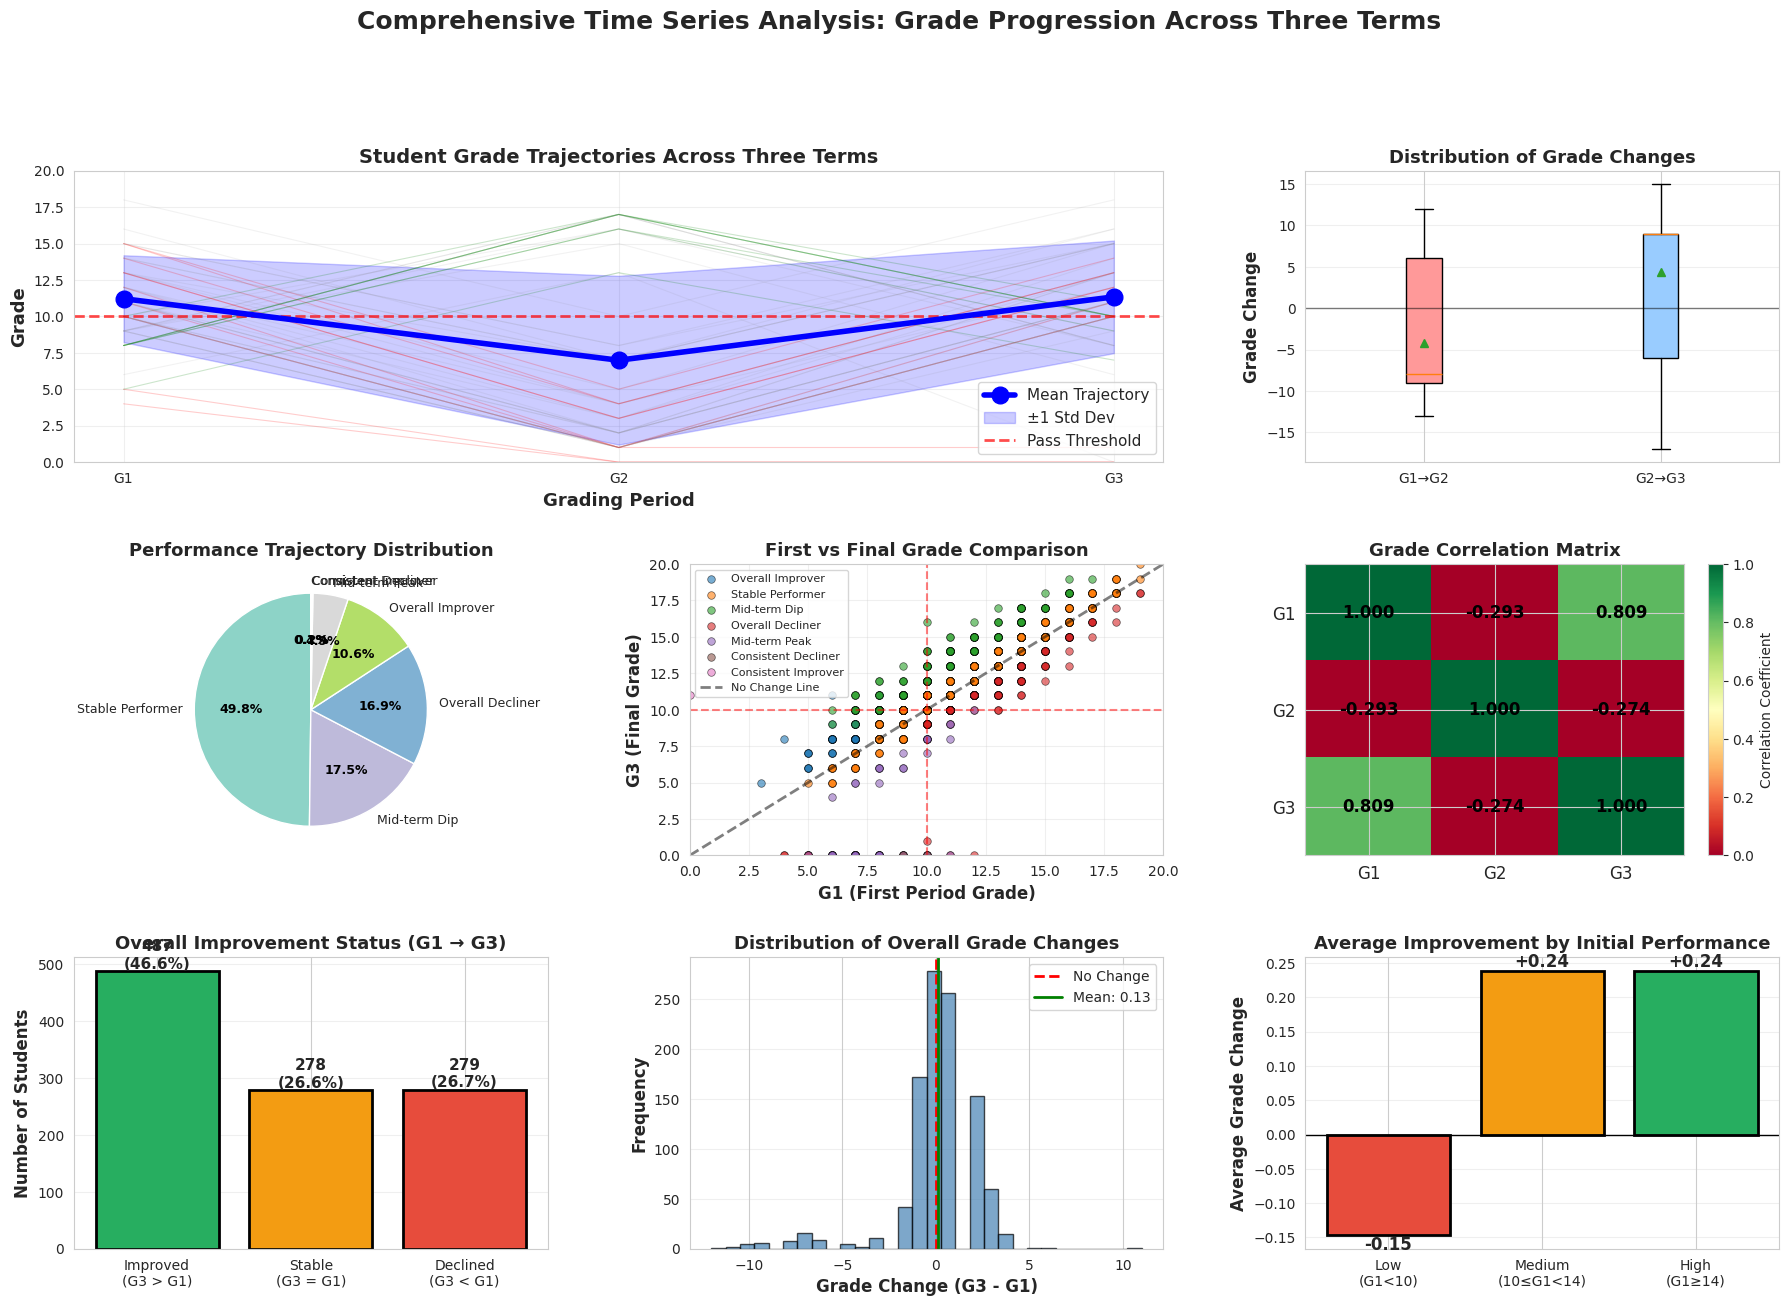

In [54]:
# Create comprehensive time series visualizations
fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Overall Grade Progression Line Plot
ax1 = fig.add_subplot(gs[0, :2])

# Sample random students for clarity (but show all in aggregate)
sample_size = 50
sample_indices = np.random.choice(df_timeseries.index, size=min(sample_size, len(df_timeseries)), replace=False)

# Plot individual trajectories (sample)
for idx in sample_indices:
    grades = [df_timeseries.loc[idx, 'G1'], df_timeseries.loc[idx, 'G2'], df_timeseries.loc[idx, 'G3']]
    trajectory = df_timeseries.loc[idx, 'Trajectory']

    if 'Improver' in trajectory:
        color, alpha = 'green', 0.2
    elif 'Decliner' in trajectory:
        color, alpha = 'red', 0.2
    else:
        color, alpha = 'gray', 0.1

    ax1.plot(['G1', 'G2', 'G3'], grades, color=color, alpha=alpha, linewidth=0.8)

# Plot mean trajectory (bold)
mean_grades = [df_timeseries['G1'].mean(), df_timeseries['G2'].mean(), df_timeseries['G3'].mean()]
ax1.plot(['G1', 'G2', 'G3'], mean_grades, color='blue', linewidth=4, marker='o',
        markersize=12, label='Mean Trajectory', zorder=5)

# Add standard deviation bands
std_grades = [df_timeseries['G1'].std(), df_timeseries['G2'].std(), df_timeseries['G3'].std()]
ax1.fill_between(range(3),
                 [m - s for m, s in zip(mean_grades, std_grades)],
                 [m + s for m, s in zip(mean_grades, std_grades)],
                 alpha=0.2, color='blue', label='\u00b11 Std Dev')

ax1.axhline(y=10, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Pass Threshold')
ax1.set_ylabel('Grade', fontsize=13, fontweight='bold')
ax1.set_xlabel('Grading Period', fontsize=13, fontweight='bold')
ax1.set_title('Student Grade Trajectories Across Three Terms', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 20)

# 2. Distribution of Grade Changes
ax2 = fig.add_subplot(gs[0, 2])

changes = [df_timeseries['G1_to_G2_change'], df_timeseries['G2_to_G3_change']]
bp = ax2.boxplot(changes, labels=['G1\u2192G2', 'G2\u2192G3'], patch_artist=True, showmeans=True)

colors = ['#ff9999', '#99ccff']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.set_ylabel('Grade Change', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Grade Changes', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Trajectory Distribution Pie Chart
ax3 = fig.add_subplot(gs[1, 0])

trajectory_counts = df_timeseries['Trajectory'].value_counts()
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(trajectory_counts)))

wedges, texts, autotexts = ax3.pie(trajectory_counts.values, labels=trajectory_counts.index, autopct='%1.1f%%',
                                     colors=colors_pie, startangle=90, textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

ax3.set_title('Performance Trajectory Distribution', fontsize=13, fontweight='bold')

# 4. Scatter: G1 vs G3 with Improvement Zones
ax4 = fig.add_subplot(gs[1, 1])

# Color by trajectory type
for trajectory in df_timeseries['Trajectory'].unique():
    traj_data = df_timeseries[df_timeseries['Trajectory'] == trajectory]
    ax4.scatter(traj_data['G1'], traj_data['G3'], label=trajectory, alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

# Add diagonal line (no change)
ax4.plot([0, 20], [0, 20], 'k--', linewidth=2, alpha=0.5, label='No Change Line')

# Add zones
ax4.axhline(y=10, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
ax4.axvline(x=10, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

ax4.set_xlabel('G1 (First Period Grade)', fontsize=12, fontweight='bold')
ax4.set_ylabel('G3 (Final Grade)', fontsize=12, fontweight='bold')
ax4.set_title('First vs Final Grade Comparison', fontsize=13, fontweight='bold')
ax4.legend(fontsize=8, loc='upper left')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 20)
ax4.set_ylim(0, 20)

# 5. Heatmap: Correlation Matrix
ax5 = fig.add_subplot(gs[1, 2])

grade_corr = df_timeseries[['G1', 'G2', 'G3']].corr()
im = ax5.imshow(grade_corr, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax5.set_xticks(range(3))
ax5.set_yticks(range(3))
ax5.set_xticklabels(['G1', 'G2', 'G3'], fontsize=12)
ax5.set_yticklabels(['G1', 'G2', 'G3'], fontsize=12)
ax5.set_title('Grade Correlation Matrix', fontsize=13, fontweight='bold')

# Add correlation values
for i in range(3):
    for j in range(3):
        text = ax5.text(j, i, f'{grade_corr.iloc[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax5, label='Correlation Coefficient')

# 6. Improvement/Decline Analysis Bar Chart
ax6 = fig.add_subplot(gs[2, 0])

improvement_categories = ['Improved\n(G3 > G1)', 'Stable\n(G3 = G1)', 'Declined\n(G3 < G1)']
improvement_counts = [len(improvers), len(stable), len(decliners)]
improvement_colors = ['#27ae60', '#f39c12', '#e74c3c']

bars = ax6.bar(improvement_categories, improvement_counts, color=improvement_colors,
              edgecolor='black', linewidth=2)

ax6.set_ylabel('Number of Students', fontsize=12, fontweight='bold')
ax6.set_title('Overall Improvement Status (G1 \u2192 G3)', fontsize=13, fontweight='bold')
ax6.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    pct = height / len(df_timeseries) * 100
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

# 7. Grade Change Histogram
ax7 = fig.add_subplot(gs[2, 1])

ax7.hist(df_timeseries['G1_to_G3_change'], bins=30, color='steelblue',
        edgecolor='black', alpha=0.7)

ax7.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
ax7.axvline(x=df_timeseries['G1_to_G3_change'].mean(), color='green',
           linestyle='-', linewidth=2, label=f'Mean: {df_timeseries["G1_to_G3_change"].mean():.2f}')

ax7.set_xlabel('Grade Change (G3 - G1)', fontsize=12, fontweight='bold')
ax7.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax7.set_title('Distribution of Overall Grade Changes', fontsize=13, fontweight='bold')
ax7.legend(fontsize=10)
ax7.grid(axis='y', alpha=0.3)

# 8. Performance by Initial Grade Level
ax8 = fig.add_subplot(gs[2, 2])

# Categorize by initial grade
def categorize_g1(g1):
    if g1 < 10:
        return 'Low\n(G1<10)'
    elif g1 < 14:
        return 'Medium\n(10\u2264G1<14)'
    else:
        return 'High\n(G1\u226514)'

df_timeseries['G1_Category'] = df_timeseries['G1'].apply(categorize_g1)

g1_categories = ['Low\n(G1<10)', 'Medium\n(10\u2264G1<14)', 'High\n(G1\u226514)']
avg_changes = []

for cat in g1_categories:
    cat_data = df_timeseries[df_timeseries['G1_Category'] == cat]
    avg_changes.append(cat_data['G1_to_G3_change'].mean())

bars = ax8.bar(g1_categories, avg_changes,
              color=['#e74c3c', '#f39c12', '#27ae60'],
              edgecolor='black', linewidth=2)

ax8.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax8.set_ylabel('Average Grade Change', fontsize=12, fontweight='bold')
ax8.set_title('Average Improvement by Initial Performance', fontsize=13, fontweight='bold')
ax8.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, avg_changes):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:+.2f}', ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=12, fontweight='bold')

plt.suptitle('Comprehensive Time Series Analysis: Grade Progression Across Three Terms',
            fontsize=18, fontweight='bold', y=0.995)
plt.savefig(f'{SAVE_DIR}/timeseries_grade_progression_dashboard.png')
plt.show()
plt.close(fig)

print("\n" + "="*80)

In [39]:
# Generate detailed interpretations based on the analysis
print("="*90)
print("KEY FINDINGS FROM TIME SERIES ANALYSIS")
print("="*90)

# 1. Overall Trends
print("\n1. OVERALL PERFORMANCE TRENDS:")
print(f"   • Average G1 (First Period): {df_timeseries['G1'].mean():.2f} \u00b1 {df_timeseries['G1'].std():.2f}")
print(f"   • Average G2 (Mid Period):   {df_timeseries['G2'].mean():.2f} \u00b1 {df_timeseries['G2'].std():.2f}")
print(f"   • Average G3 (Final):        {df_timeseries['G3'].mean():.2f} \u00b1 {df_timeseries['G3'].std():.2f}")

overall_trend = df_timeseries['G3'].mean() - df_timeseries['G1'].mean()
if overall_trend > 0:
    print(f"   \u2713 Positive Trend: Students improve by {overall_trend:.2f} points on average from G1 to G3")
elif overall_trend < 0:
    print(f"   \u2717 Negative Trend: Students decline by {abs(overall_trend):.2f} points on average from G1 to G3")
else:
    print(f"   \u2192 Stable Trend: Overall performance remains constant")

# 2. Trajectory Analysis
print("\n2. PERFORMANCE TRAJECTORY INSIGHTS:")
print(f"   • Total Students Analyzed: {len(df_timeseries)}")
print(f"   • Improvers (G3 > G1): {len(improvers)} ({len(improvers)/len(df_timeseries)*100:.1f}%)")
print(f"   • Stable (G3 = G1): {len(stable)} ({len(stable)/len(df_timeseries)*100:.1f}%)")
print(f"   • Decliners (G3 < G1): {len(decliners)} ({len(decliners)/len(df_timeseries)*100:.1f}%)")

print("\n   Most Common Trajectories:")
top_trajectories = df_timeseries['Trajectory'].value_counts().head(5)
for i, (traj, count) in enumerate(top_trajectories.items(), 1):
    print(f"   {i}. {traj}: {count} students ({count/len(df_timeseries)*100:.1f}%)")

# 3. Correlation Insights
print("\n3. PREDICTIVE RELATIONSHIPS:")
# Corrected variable names to match what was defined in the previous cell
print(f"   • G1 \u2194 G2 Correlation: r = {corr_g1_g2:.3f} (p-value: {p_g1_g2:.4f})")
print(f"   • G2 \u2194 G3 Correlation: r = {corr_g2_g3:.3f} (p-value: {p_g2_g3:.4f})")
print(f"   • G1 \u2194 G3 Correlation: r = {corr_g1_g3:.3f} (p-value: {p_g1_g3:.4f})")

# Determine strongest predictor
correlations = {'G1': corr_g1_g3, 'G2': corr_g2_g3} # Use corr_ variables
strongest_predictor = max(correlations, key=correlations.get)
print(f"\n   \u2192 {strongest_predictor} is the strongest predictor of final grade (G3)")
print(f"     {correlations[strongest_predictor]:.3f} (r) explains {correlations[strongest_predictor]**2 * 100:.1f}% of G3 variance")

# 4. At-Risk Students
# Use at_risk_early and at_risk_final_fail from the previous cell
at_risk_total = len(at_risk_early)
recovery_count = at_risk_total - len(at_risk_final_fail)
recovery_rate = (recovery_count / at_risk_total * 100) if at_risk_total > 0 else 0

print("\n4. AT-RISK STUDENT IDENTIFICATION:")
print(f"   • Students with G1 or G2 < 10: {at_risk_total} ({at_risk_total/len(df_timeseries)*100:.1f}%)")
print(f"   • Students who recovered (G3 \u2265 10): {recovery_count} ({recovery_rate:.1f}% recovery rate)")
print(f"   • Students who remained at-risk: {len(at_risk_final_fail)}")

if recovery_rate > 50:
    print(f"\n   \u2713 Good Recovery Rate: More than half of struggling students improved to passing")
else:
    print(f"\n   \u2717 Low Recovery Rate: Majority of struggling students did not reach passing threshold")

# 5. Performance by Initial Level
print("\n5. IMPROVEMENT BY INITIAL PERFORMANCE LEVEL:")
low_performers = df_timeseries[df_timeseries['G1'] < 10]
mid_performers = df_timeseries[(df_timeseries['G1'] >= 10) & (df_timeseries['G1'] < 14)]
high_performers = df_timeseries[df_timeseries['G1'] >= 14]

# Handle cases where a category might be empty to avoid NaN in print
low_avg_change = low_performers['G1_to_G3_change'].mean() if not low_performers.empty else 0.0
mid_avg_change = mid_performers['G1_to_G3_change'].mean() if not mid_performers.empty else 0.0
high_avg_change = high_performers['G1_to_G3_change'].mean() if not high_performers.empty else 0.0

print(f"   • Low Initial (G1<10): Avg change = {low_avg_change:+.2f} points")
print(f"   • Medium Initial (10\u2264G1<14): Avg change = {mid_avg_change:+.2f} points")
print(f"   • High Initial (G1\u226514): Avg change = {high_avg_change:+.2f} points")

# 6. Critical Periods
print("\n6. CRITICAL PERFORMANCE PERIODS:")
g1_to_g2_avg = df_timeseries['G1_to_G2_change'].mean()
g2_to_g3_avg = df_timeseries['G2_to_G3_change'].mean()

print(f"   • Average G1\u2192G2 Change: {g1_to_g2_avg:+.2f} points")
print(f"   • Average G2\u2192G3 Change: {g2_to_g3_avg:+.2f} points")

if abs(g1_to_g2_avg) > abs(g2_to_g3_avg):
    print(f"\n   \u2192 First half (G1\u2192G2) shows greater change - critical intervention period")
else:
    print(f"\n   \u2192 Second half (G2\u2192G3) shows greater change - late-term effects significant")

print("\n" + "="*90)
print("EDUCATIONAL RECOMMENDATIONS BASED ON TIME SERIES ANALYSIS")
print("="*90)

recommendations = [
    "\n1. EARLY WARNING SYSTEM:",
    "   • Implement G1-based screening to identify at-risk students immediately",
    "   • Students with G1 < 10 should receive immediate support interventions",
    f"   • Focus on {at_risk_total} students identified as at-risk in first period",

    "\n2. INTERVENTION TIMING:",
    "   • Critical intervention window: Between G1 and G2 assessments",
    "   • Mid-term support for students showing decline in G2",
    "   • Continuous monitoring rather than end-of-term assessment only",

    "\n3. PERSONALIZED SUPPORT STRATEGIES:",
    f"   • For Consistent Decliners ({trajectory_counts.get('Consistent Decliner', 0)} students):",
    "     - Investigate underlying causes (motivation, health, external factors)",
    "     - Consider course difficulty adjustment or additional tutoring",
    f"   • For Erratic Performers ({trajectory_counts.get('Erratic', 0)} students):",
    "     - Focus on study consistency and time management skills",
    "     - Provide structured learning environment",
    f"   • For Mid-term Dip ({trajectory_counts.get('Mid-term Dip', 0)} students):",
    "     - Investigate G2 assessment difficulty or teaching changes",
    "     - Provide recovery support to maintain G3 improvement",

    "\n4. SUCCESS REPLICATION:",
    f"   • Study Consistent Improvers ({trajectory_counts.get('Consistent Improver', 0)} students):",
    "     - Identify common study habits, support systems, or teaching methods",
    "     - Share best practices with struggling students",
    "     - Create peer mentoring programs",

    "\n5. PREDICTIVE MODELING:",
    f"   • Use {strongest_predictor} as primary predictor for final outcomes",
    "   • Develop early prediction models to forecast G3 from G1 and G2",
    "   • Set intervention thresholds based on historical recovery rates",

    "\n6. CURRICULUM INSIGHTS:",
    "   • Analyze why certain trajectories are more common",
    "   • Investigate if grade distribution shifts indicate curriculum issues",
    "   • Consider if assessment difficulty is appropriately calibrated across terms",

    "\n7. MONITORING DASHBOARD:",
    "   • Create real-time tracking system for student trajectories",
    "   • Flag students showing negative trends immediately",
    "   • Provide instructors with actionable alerts between grading periods"
]

for rec in recommendations:
    print(rec)

print("\n" + "="*90)
print("CONCLUSION:")
print("="*90)
print("""
Time series analysis reveals that student performance is NOT static - it evolves significantly
across the academic term. This analysis demonstrates:

\u2713 Early grades are strong predictors but not deterministic - interventions matter
\u2713 Different students follow distinct trajectory patterns requiring personalized approaches
\u2713 Critical intervention windows exist where support can change outcomes
\u2713 Recovery from early struggles is possible but requires targeted support

The key to improving student outcomes is EARLY IDENTIFICATION + CONTINUOUS MONITORING +
TIMELY INTERVENTION rather than waiting for final assessments.
""")

KEY FINDINGS FROM TIME SERIES ANALYSIS

1. OVERALL PERFORMANCE TRENDS:
   • Average G1 (First Period): 11.21 ± 2.98
   • Average G2 (Mid Period):   6.99 ± 5.79
   • Average G3 (Final):        11.34 ± 3.86
   ✓ Positive Trend: Students improve by 0.13 points on average from G1 to G3

2. PERFORMANCE TRAJECTORY INSIGHTS:
   • Total Students Analyzed: 1044
   • Improvers (G3 > G1): 487 (46.6%)
   • Stable (G3 = G1): 278 (26.6%)
   • Decliners (G3 < G1): 279 (26.7%)

   Most Common Trajectories:
   1. Stable Performer: 520 students (49.8%)
   2. Mid-term Dip: 183 students (17.5%)
   3. Overall Decliner: 176 students (16.9%)
   4. Overall Improver: 111 students (10.6%)
   5. Mid-term Peak: 51 students (4.9%)

3. PREDICTIVE RELATIONSHIPS:
   • G1 ↔ G2 Correlation: r = -0.293 (p-value: 0.0000)
   • G2 ↔ G3 Correlation: r = -0.274 (p-value: 0.0000)
   • G1 ↔ G3 Correlation: r = 0.809 (p-value: 0.0000)

   → G1 is the strongest predictor of final grade (G3)
     0.809 (r) explains 65.5% of G3 va